# Applying Machine Learning to Test Whether Texas Childcare Inspections Reflect Family Experience
**UC Berkeley - Professional Certificate in ML/AI**  
**Rakesh Chandrasekaran**  
**Capstone Assignment 20.1: Initial Report and Exploratory Data Analysis (EDA)**

---

### Research Question
Can Texas childcare licensing records predict the Google ratings that families assign to daycare centers across the five largest Texas cities as accurately as a model built from the review text those same families wrote?

### Scope
- **Cities:** Austin · Houston · San Antonio · Dallas · Fort Worth
- **Model 1 (regulatory):** HHSC inspection and licensing features → Google star rating (Ridge Regression baseline; XGBoost + SHAP in Module 24)
- **Model 2 (NLP):** Google review text via TF-IDF → Google star rating (Module 24)

### Notebook Structure
0. Setup
1. Download HHSC Data
2. Google Places Matching
3. Match Quality Validation
4. Fetch Ratings and Reviews
5. Coverage Assessment
6. Feature Engineering
7. Data Overview and Cleaning
8. Exploratory Data Analysis
   - 8.1 Target Variable — Google Star Rating
   - 8.2 Regulatory Feature Distributions (deficiency counts, rate and scale features, binary features)
   - 8.3 Feature Correlations with Google Rating
   - 8.4 Scatter Plots — Regulatory Features vs Google Rating
   - 8.5 Outlier Analysis
   - 8.6 Review Text Overview (Model 2 Input Data)
   - 8.7 EDA Summary and Interpretation
9. Baseline Model (Model 1)
   - 9.1 Prepare Model Data
   - 9.2 Naive Baseline
   - 9.3 Model Comparison with GridSearchCV
   - 9.4 Polynomial Analysis
   - 9.5 Ridge Regression Diagnostics
     - 9.5.1 Performance Summary
     - 9.5.2 Predicted vs Actual Plot
     - 9.5.3 Feature Coefficient Plot
10. Export Datasets
11. Summary and Next Steps


## 0. Setup

In [5]:
# ── Data manipulation and numerical computing ─────────────────────────────
import pandas as pd
import numpy as np

# ── Visualization ─────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── HTTP requests, caching, and file I/O ──────────────────────────────────
import requests, time, json, os
from datetime import datetime

# ── Fuzzy string matching for Google Places name validation ───────────────
from rapidfuzz import fuzz

# ── Scikit-learn: preprocessing and pipeline ──────────────────────────────
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder
from sklearn.pipeline import Pipeline

# ── Scikit-learn: models ──────────────────────────────────────────────────
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.dummy import DummyRegressor

# ── Scikit-learn: model selection and evaluation ──────────────────────────
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Suppress deprecation warnings to keep notebook output clean
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 80)
sns.set_theme(style='whitegrid', palette='muted')

print("Libraries loaded.")

Libraries loaded.


In [6]:
# ── Analysis Constants ────────────────────────────────────────────────────
# Cities in scope for this study
TARGET_CITIES = ["AUSTIN", "HOUSTON", "SAN ANTONIO", "DALLAS", "FORT WORTH"]

# Fixed reference date for computing YEARS_IN_OPERATION from each center's ISSUANCE_DATE.
# Using a fixed date (rather than datetime.today()) ensures the feature value is identical
# every time the notebook is run, keeping results reproducible and the feature consistent
# between training and any future inference.
REFERENCE_DATE = datetime(2026, 1, 1)

# 15 features engineered in Section 6 from raw HHSC fields — inputs to Model 1.
# HAS_ADVERSE_ACTION and WAS_TEMP_CLOSED are excluded: HHSC stores 'NO' for all
# centers in this dataset, producing zero-variance columns that carry no signal.
# HAS_CORRECTIVE_ACTION is retained despite low prevalence (0.5%) — Ridge will
# assign it a near-zero coefficient if it contributes nothing.
FEATURE_COLS = [
    'DEFICIENCY_HIGH', 'DEFICIENCY_MEDIUM_HIGH', 'DEFICIENCY_MEDIUM',
    'DEFICIENCY_MEDIUM_LOW', 'DEFICIENCY_LOW', 'TOTAL_DEFICIENCIES',
    'DEFICIENCY_RATE', 'HIGH_DEFICIENCY_RATE', 'TOTAL_CAPACITY',
    'TOTAL_INSPECTIONS', 'TOTAL_ASSESSMENTS', 'YEARS_IN_OPERATION',
    'IS_ACCREDITED', 'ACCEPTS_SUBSIDIES', 'HAS_CORRECTIVE_ACTION'
]

# ── Directory Configuration ───────────────────────────────────────────────
# BASE_DIR is loaded from an environment variable so the notebook runs on any
# machine without hardcoded paths. Set it before launching Jupyter:
#   export CAPSTONE_BASE_DIR="/path/to/ucbmlai-Capstone-TX-Top5-ChildCare"
BASE_DIR      = os.environ.get("CAPSTONE_BASE_DIR", os.getcwd())
RAW_DIR       = os.path.join(BASE_DIR, "data", "raw")
PROCESSED_DIR = os.path.join(BASE_DIR, "data", "processed")
IMAGES_DIR    = os.path.join(BASE_DIR, "images")

# Create directories if they don't already exist
for d in [RAW_DIR, PROCESSED_DIR, IMAGES_DIR]:
    os.makedirs(d, exist_ok=True)

# ── File Paths ────────────────────────────────────────────────────────────
# Raw HHSC download and Google Places API cache files
HHSC_CSV        = os.path.join(RAW_DIR, "hhsc_data.csv")
PLACE_IDS_CACHE = os.path.join(RAW_DIR, "place_ids.json")     # place_id lookup cache
DETAILS_CACHE   = os.path.join(RAW_DIR, "place_details.json") # ratings + reviews cache

# ── API Key ───────────────────────────────────────────────────────────────
# Loaded from environment variable — do not hardcode or commit to a public repo
#   export GOOGLE_API_KEY="your-key-here"
GOOGLE_API_KEY = os.environ.get("GOOGLE_API_KEY", "")

# ── Validation ────────────────────────────────────────────────────────────
if not os.environ.get("GOOGLE_API_KEY"):
    print("WARNING: GOOGLE_API_KEY env variable is not set — API calls will fail.")
if not os.environ.get("CAPSTONE_BASE_DIR"):
    print(f"NOTE: CAPSTONE_BASE_DIR not set — defaulting to cwd: {BASE_DIR}")

print("Configuration complete.")
print(f"  Cities:         {TARGET_CITIES}")
print(f"  Reference date: {REFERENCE_DATE.strftime('%Y-%m-%d')}")
print(f"  Features:       {len(FEATURE_COLS)} (Model 1 inputs)")
print(f"  Base dir:       {BASE_DIR}")
print(f"  Raw data:       {RAW_DIR}")
print(f"  Processed data: {PROCESSED_DIR}")
print(f"  Images:         {IMAGES_DIR}")

Configuration complete.
  Cities:         ['AUSTIN', 'HOUSTON', 'SAN ANTONIO', 'DALLAS', 'FORT WORTH']
  Reference date: 2026-01-01
  Base dir:       /Users/rakesh/Documents/CISO/Certifications/UCBMLAI/Capstone/ucbmlai-Capstone-TX-Top5-ChildCare
  Raw data:       /Users/rakesh/Documents/CISO/Certifications/UCBMLAI/Capstone/ucbmlai-Capstone-TX-Top5-ChildCare/data/raw
  Processed data: /Users/rakesh/Documents/CISO/Certifications/UCBMLAI/Capstone/ucbmlai-Capstone-TX-Top5-ChildCare/data/processed
  Images:         /Users/rakesh/Documents/CISO/Certifications/UCBMLAI/Capstone/ucbmlai-Capstone-TX-Top5-ChildCare/images


<div style="background:#fff8e1; border-left:4px solid #f9a825; padding:12px 16px; border-radius:4px; margin:8px 0;">
<b>Before re-running:</b> Sections 1–3 make live API calls to the Texas HHSC data portal and the Google Places API. Re-running these sections requires a valid <code>GOOGLE_API_KEY</code> set in a <code>.env</code> file at the project root. To skip data extraction and resume from saved data, start from Section 6 — the reload checkpoint cell loads <code>df_matched_rated.pkl</code> directly from <code>data/processed/</code>.
</div>

## 1. Download HHSC Data

The Texas HHSC publishes a daily-updated CSV of all licensed childcare facilities statewide.
The data is downloaded fresh, filtered to active licensed centers in the 5 target cities, and records
with missing addresses are dropped — the only filter applied at this stage, since address is required for Google Places matching.
All other feature engineering is deferred to Section 6 after ratings are fetched.

In [7]:
# Texas HHSC publishes a daily-updated CSV of all licensed childcare facilities statewide
HHSC_URL = "https://data.texas.gov/views/bc5r-88dy/rows.csv?accessType=DOWNLOAD"

print("Downloading HHSC licensed childcare facility data (fresh)...")
# stream=True avoids loading the full file (~10 MB) into memory before writing;
# timeout=180 allows for slow responses from the Texas.gov server
resp = requests.get(HHSC_URL, stream=True, timeout=180)
resp.raise_for_status()  # abort immediately if the server returns an error status

with open(HHSC_CSV, 'wb') as f:
    for chunk in resp.iter_content(chunk_size=16384):
        f.write(chunk)

size_mb = os.path.getsize(HHSC_CSV) / 1024 / 1024
print(f"Downloaded: {HHSC_CSV}  ({size_mb:.1f} MB)")

Downloaded: /Users/rakesh/Documents/CISO/Certifications/UCBMLAI/Capstone/ucbmlai-Capstone-TX-Top5-ChildCare/data/raw/hhsc_data.csv  (7.6 MB)


In [8]:
# Read everything as strings to prevent pandas from auto-casting OPERATION_ID,
# phone numbers, or date-like codes to numeric/datetime types
df_raw = pd.read_csv(HHSC_CSV, dtype=str, low_memory=False)

# Normalize before filtering — inconsistent whitespace or casing in the source
# data would silently drop rows that should match
df_raw['CITY']             = df_raw['CITY'].str.strip().str.upper()
df_raw['OPERATION_TYPE']   = df_raw['OPERATION_TYPE'].str.strip()
df_raw['OPERATION_STATUS'] = df_raw['OPERATION_STATUS'].str.strip()

# Keep only: active ('Y') licensed centers in the 5 target cities.
# 'Licensed Center' excludes home-based (registered) facilities and other operation types.
df = df_raw[
    (df_raw['CITY'].isin(TARGET_CITIES)) &
    (df_raw['OPERATION_TYPE'] == 'Licensed Center') &
    (df_raw['OPERATION_STATUS'] == 'Y')
].copy().reset_index(drop=True)  # .copy() prevents SettingWithCopyWarning on later assignments

# Drop centers with no address — Google Places matching requires name + address.
# All other quality filters are deferred to Section 6 (Feature Engineering).
n_before = len(df)
df = df[df['ADDRESS_LINE'].notna() & (df['ADDRESS_LINE'].str.strip() != '')]
df = df.reset_index(drop=True)

print(f"Raw HHSC rows:                      {len(df_raw):,}")
print(f"Active Licensed Centers (5 cities): {n_before:,}")
print(f"After removing missing addresses:   {len(df):,}  (dropped {n_before - len(df):,})")
print()
print(df['CITY'].value_counts().to_string())

Raw HHSC rows:                      15,141
Active Licensed Centers (5 cities): 2,516
After removing missing addresses:   2,516  (dropped 0)

CITY
HOUSTON        935
SAN ANTONIO    501
AUSTIN         480
DALLAS         342
FORT WORTH     258


## 2. Google Places Matching

Each HHSC-licensed center is matched to its Google Places listing by name + address.
Results are cached to a local JSON file so the run can be resumed if interrupted.

**API:** `findplacefromtext` with a 25 km location bias centred on each city
**Estimated cost:** ~$0.017 per call × ~2,500 centers ≈ **$42**

In [9]:
# Geographic centers used as locationbias anchors — biases Google Places results
# toward each city so common chain names (e.g. "KinderCare") match the correct location
CITY_CENTROIDS = {
    'AUSTIN':       '30.2672,-97.7431',
    'HOUSTON':      '29.7604,-95.3698',
    'SAN ANTONIO':  '29.4241,-98.4936',
    'DALLAS':       '32.7767,-96.7970',
    'FORT WORTH':   '32.7555,-97.3308',
}

def find_place(name, address, city, api_key=GOOGLE_API_KEY):
    query = f"{name} {address} {city} TX"
    url   = "https://maps.googleapis.com/maps/api/place/findplacefromtext/json"
    params = {
        'input':        query,
        'inputtype':    'textquery',
        'fields':       'place_id,name,formatted_address',
        # 25 km radius bias — wide enough for suburbs, tight enough to exclude other TX cities
        'locationbias': f"circle:25000@{CITY_CENTROIDS.get(city.upper(), '31.0,-97.0')}",
        'key':          api_key,
    }
    try:
        resp = requests.get(url, params=params, timeout=10)
        data = resp.json()
        if data.get('status') == 'REQUEST_DENIED':
            raise Exception(f"API key error: {data.get('error_message')}")
        candidates = data.get('candidates', [])
        if candidates:
            c = candidates[0]
            return {'place_id': c.get('place_id'), 'google_name': c.get('name'),
                    'google_address': c.get('formatted_address'), 'match_status': 'found'}
    except Exception as e:
        return {'place_id': None, 'google_name': None,
                'google_address': None, 'match_status': f'error: {e}'}
    return {'place_id': None, 'google_name': None,
            'google_address': None, 'match_status': 'not_found'}

# Verify the API key is valid before running the full matching loop
print("Testing API key...")
test = find_place("La Petite Academy", "5555 Main St", "Houston")
if test['match_status'].startswith('error'):
    print(f"API ERROR: {test['match_status']}")
else:
    print(f"API OK — {test['google_name']} | {test['google_address']}")

Testing API key...
API OK — La Petite Academy on W. 18th St. | 1810 W 18th St, Houston, TX 77008, USA


In [10]:
# Load existing cache — allows resuming an interrupted run without re-calling the API
if os.path.exists(PLACE_IDS_CACHE):
    with open(PLACE_IDS_CACHE) as f:
        cache = json.load(f)
    print(f"Loaded cache: {len(cache):,} records")
else:
    cache = {}
    print("Starting fresh cache")

already_done = sum(1 for r in df['OPERATION_ID'].astype(str) if r in cache)
remaining    = len(df) - already_done
est_minutes  = remaining * 0.3 / 60  # ~0.3s per call (network + 0.05s sleep)
print(f"Already cached: {already_done:,} | Remaining: {remaining:,}")
print(f"Estimated API cost:    ~${remaining * 0.017:.2f}")
print(f"Estimated run time:    ~{est_minutes:.1f} minutes\n")

results    = []
start_time = time.time()

for i, (_, row) in enumerate(df.iterrows()):
    op_id = str(row['OPERATION_ID'])

    if op_id in cache:
        # Already fetched in a previous run — use cached result, no API call
        results.append({'OPERATION_ID': op_id, **cache[op_id]})
    else:
        match = find_place(row['OPERATION_NAME'], row['ADDRESS_LINE'], row['CITY'])
        if match['match_status'].startswith('error'):
            # Hard API error (bad key, quota exceeded) — stop immediately to avoid burning budget
            print(f"  [ERROR] record {i}: {match['match_status']} — stopping early")
            break
        # Store without OPERATION_ID key to avoid duplication when merging later
        cache[op_id] = {k: v for k, v in match.items() if k != 'OPERATION_ID'}
        results.append({'OPERATION_ID': op_id, **match})
        time.sleep(0.05)  # stay well within Google's 50 QPS rate limit

    # Every 50 records: log progress and write cache to disk.
    # If the run is interrupted, the next restart will reload the file and skip
    # already-fetched records, so at most 50 API calls need to be repeated.
    if (i + 1) % 50 == 0 or (i + 1) == len(df):
        elapsed       = time.time() - start_time
        api_calls     = i + 1 - already_done  # exclude cached records from rate calculation
        rate          = api_calls / elapsed if elapsed > 0 else 0
        remaining_now = len(df) - (i + 1)
        eta           = (remaining_now / rate) / 60 if rate > 0 else 0
        found         = sum(1 for r in results if r.get('place_id'))

        print(f"  [{i+1:>4}/{len(df)}] matched: {found:,} | city: {row['CITY']:<12} | "
              f"elapsed: {elapsed/60:.1f}m | ETA: {eta:.1f}m")

        with open(PLACE_IDS_CACHE, 'w') as f:
            json.dump(cache, f)

# Final flush ensures the last batch is written even if len(df) is not a multiple of 50
with open(PLACE_IDS_CACHE, 'w') as f:
    json.dump(cache, f)

df_pids = pd.DataFrame(results)
df      = df.merge(df_pids, on='OPERATION_ID', how='left')
found_n = df['place_id'].notna().sum()

total_elapsed = (time.time() - start_time) / 60
print(f"\nMatching complete: {found_n:,}/{len(df):,} ({found_n/len(df)*100:.1f}%) in {total_elapsed:.1f} minutes")

Starting fresh cache
Already cached: 0 | Remaining: 2,516
Estimated API cost:    ~$42.77
Estimated run time:    ~12.6 minutes

  [  50/2516] matched: 50 | city: HOUSTON      | elapsed: 0.3m | ETA: 16.9m
  [ 100/2516] matched: 100 | city: HOUSTON      | elapsed: 0.7m | ETA: 17.0m
  [ 150/2516] matched: 150 | city: HOUSTON      | elapsed: 1.1m | ETA: 16.7m
  [ 200/2516] matched: 200 | city: HOUSTON      | elapsed: 1.4m | ETA: 16.2m
  [ 250/2516] matched: 250 | city: DALLAS       | elapsed: 1.7m | ETA: 15.8m
  [ 300/2516] matched: 300 | city: HOUSTON      | elapsed: 2.1m | ETA: 15.5m
  [ 350/2516] matched: 350 | city: SAN ANTONIO  | elapsed: 2.5m | ETA: 15.2m
  [ 400/2516] matched: 398 | city: HOUSTON      | elapsed: 2.8m | ETA: 14.9m
  [ 450/2516] matched: 448 | city: DALLAS       | elapsed: 3.2m | ETA: 14.6m
  [ 500/2516] matched: 498 | city: AUSTIN       | elapsed: 3.5m | ETA: 14.2m
  [ 550/2516] matched: 548 | city: AUSTIN       | elapsed: 3.8m | ETA: 13.7m
  [ 600/2516] matched: 597 

## 3. Match Quality Validation

Fuzzy name matching (`token_sort_ratio`) is used to classify each match as high, medium, or low confidence.
Only high- and medium-confidence matches are carried forward for ratings retrieval and model training.

In [12]:
def name_similarity(a, b):
    if pd.isna(a) or pd.isna(b): return 0
    # token_sort_ratio sorts tokens before comparing — handles "KinderCare Learning Center"
    # vs "Learning Center KinderCare" (same name, different word order)
    return fuzz.token_sort_ratio(str(a).lower(), str(b).lower())

df['name_similarity'] = df.apply(
    lambda r: name_similarity(r['OPERATION_NAME'], r['google_name']), axis=1)

def classify_match(row):
    if pd.isna(row['place_id']):     return 'no_match'
    # Thresholds chosen empirically: ≥80 captures near-exact matches (minor suffix differences);
    # 50–79 catches abbreviated names like "La Petite" vs "La Petite Academy"
    if row['name_similarity'] >= 80: return 'high_confidence'
    if row['name_similarity'] >= 50: return 'medium_confidence'
    return 'low_confidence'

df['match_confidence'] = df.apply(classify_match, axis=1)

print("Match confidence distribution (score out of 100):")
print(df['match_confidence'].value_counts().to_string())
print()

# Score statistics per confidence tier
score_stats = (df.groupby('match_confidence')['name_similarity']
               .agg(['min', 'median', 'mean', 'max'])
               .round(1))
print("Name similarity score by confidence tier:")
print(score_stats.to_string())
print()

# Kept for downstream modelling (Section 4 fetch ratings, Section 6 feature engineering, Section 9 model)
kept    = df['match_confidence'].isin(['high_confidence', 'medium_confidence']).sum()
dropped = len(df) - kept
print(f"Kept (high + medium confidence): {kept:,}  →  used for ratings fetch and modelling")
print(f"Dropped (low + no_match):        {dropped:,}  →  excluded from all downstream steps")
print()
print("By city:")
print(pd.crosstab(df['CITY'], df['match_confidence']).to_string())

Match confidence distribution (score out of 100):
match_confidence
high_confidence      1357
medium_confidence     907
low_confidence        245
no_match                7

Name similarity score by confidence tier:
                    min  median  mean    max
match_confidence                            
high_confidence    80.0   100.0  95.5  100.0
low_confidence     14.8    41.8  39.7   49.4
medium_confidence  50.0    65.8  65.6   79.6
no_match            0.0     0.0   0.0    0.0

Kept (high + medium confidence): 2,264  →  used for ratings fetch and modelling
Dropped (low + no_match):        252  →  excluded from all downstream steps

By city:
match_confidence  high_confidence  low_confidence  medium_confidence  no_match
CITY                                                                          
AUSTIN                        211              70                197         2
DALLAS                        195              34                113         0
FORT WORTH                    113

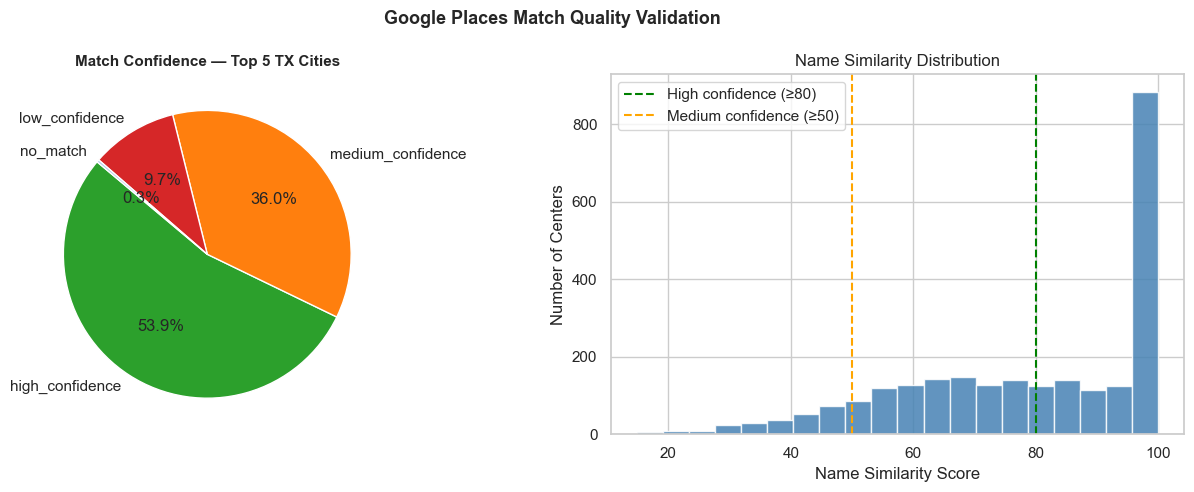

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

conf_counts = df['match_confidence'].value_counts()
color_map   = {'high_confidence': '#2ca02c', 'medium_confidence': '#ff7f0e',
               'low_confidence': '#d62728',  'no_match': '#aec7e8'}
axes[0].pie(conf_counts.values, labels=conf_counts.index, autopct='%1.1f%%',
            colors=[color_map.get(k, 'grey') for k in conf_counts.index], startangle=140)
axes[0].set_title('Match Confidence — Top 5 TX Cities', fontsize=11, fontweight='bold')

matched_df = df[df['place_id'].notna()]
axes[1].hist(matched_df['name_similarity'], bins=20, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(80, color='green',  linestyle='--', linewidth=1.5, label='High confidence (≥80)')
axes[1].axvline(50, color='orange', linestyle='--', linewidth=1.5, label='Medium confidence (≥50)')
axes[1].set_xlabel('Name Similarity Score')
axes[1].set_ylabel('Number of Centers')
axes[1].set_title('Name Similarity Distribution')
axes[1].legend()

plt.suptitle('Google Places Match Quality Validation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'match_quality_validation.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Fetch Google Ratings and Reviews

For each high- or medium-confidence match, the `place/details` API is called to retrieve:
- `rating` — the overall Google star rating (the **model target**)
- `user_ratings_total` — total review count on the platform
- `reviews` — up to 5 most-relevant review texts and individual ratings

Results are cached; re-running the cell skips already-fetched records.

In [15]:
def get_place_details(place_id, api_key=GOOGLE_API_KEY):
    url    = "https://maps.googleapis.com/maps/api/place/details/json"
    params = {'place_id': place_id,
               # Fetch only the fields we need — billing is per field; unused fields cost extra
               'fields':  'name,rating,user_ratings_total,reviews',
               'key':     api_key}
    try:
        resp    = requests.get(url, params=params, timeout=10)
        data    = resp.json().get('result', {})
        reviews = data.get('reviews', [])
        return {
            'google_rating':          data.get('rating'),
            'google_review_count':    data.get('user_ratings_total'),
            # Google Places returns at most 5 reviews per call (API limit)
            'review_texts':           [r.get('text', '') for r in reviews],
            'review_ratings':         [r.get('rating') for r in reviews],
            'review_count_returned':  len(reviews),
        }
    except Exception as e:
        return {'google_rating': None, 'google_review_count': None,
                'review_texts': [], 'review_ratings': [], 'review_count_returned': 0}


if os.path.exists(DETAILS_CACHE):
    with open(DETAILS_CACHE) as f:
        details_cache = json.load(f)
    print(f"Loaded details cache: {len(details_cache)} records")
else:
    details_cache = {}
    print("Starting fresh details cache")

# Only fetch high/medium confidence matches — low confidence matches are likely wrong places
df_fetch     = df[df['match_confidence'].isin(['high_confidence', 'medium_confidence'])].copy()
already_done = sum(1 for pid in df_fetch['place_id'] if pid in details_cache)
remaining    = len(df_fetch) - already_done
print(f"Centers to fetch: {len(df_fetch):,} | Cached: {already_done:,} | Remaining: {remaining:,}")
print(f"Estimated API cost: ~${remaining * 0.017:.2f}")

Starting fresh details cache
Centers to fetch: 2,264 | Cached: 0 | Remaining: 2,264
Estimated API cost: ~$38.49


In [16]:
detail_rows  = []
start_time   = time.time()
already_done = sum(1 for pid in df_fetch['place_id'] if pid in details_cache)

for i, (_, row) in enumerate(df_fetch.iterrows()):
    pid = row['place_id']
    if pid in details_cache:
        # Cache hit — no API call needed
        detail_rows.append({'place_id': pid, **details_cache[pid]})
    else:
        details = get_place_details(pid)
        details_cache[pid] = details
        detail_rows.append({'place_id': pid, **details})
        time.sleep(0.05)  # stay within Google's 50 QPS rate limit

    # Flush cache every 50 records so an interrupted run loses at most 50 API calls
    if (i + 1) % 50 == 0 or (i + 1) == len(df_fetch):
        elapsed       = time.time() - start_time
        api_calls     = i + 1 - already_done  # exclude cached records from rate calculation
        rate          = api_calls / elapsed if elapsed > 0 else 0
        remaining_now = len(df_fetch) - (i + 1)
        eta           = (remaining_now / rate) / 60 if rate > 0 else 0
        with_rating   = sum(1 for r in detail_rows if r.get('google_rating'))

        print(f"  [{i+1:>4}/{len(df_fetch)}] with ratings: {with_rating:,} | city: {row['CITY']:<12} | "
              f"elapsed: {elapsed/60:.1f}m | ETA: {eta:.1f}m")

        with open(DETAILS_CACHE, 'w') as f:
            json.dump(details_cache, f)

# Final flush ensures the last batch is written even if len(df_fetch) is not a multiple of 50
with open(DETAILS_CACHE, 'w') as f:
    json.dump(details_cache, f)

# Merge ratings back to the matched centers dataframe
df_details    = pd.DataFrame(detail_rows)
df_final      = df_fetch.merge(df_details, on='place_id', how='left')
total_elapsed = (time.time() - start_time) / 60

print(f"\nDetails complete in {total_elapsed:.1f} minutes:")
print(f"  Centers with ratings:    {df_final['google_rating'].notna().sum():,}")
print(f"  Centers with 3+ reviews: {(df_final['review_count_returned'] >= 3).sum():,}")
print(f"  Total reviews collected: {int(df_final['review_count_returned'].sum()):,}")

  [  50/2264] with ratings: 41 | city: HOUSTON      | elapsed: 0.2m | ETA: 7.5m
  [ 100/2264] with ratings: 82 | city: HOUSTON      | elapsed: 0.3m | ETA: 7.5m
  [ 150/2264] with ratings: 113 | city: SAN ANTONIO  | elapsed: 0.5m | ETA: 7.2m
  [ 200/2264] with ratings: 156 | city: HOUSTON      | elapsed: 0.7m | ETA: 7.0m
  [ 250/2264] with ratings: 194 | city: FORT WORTH   | elapsed: 0.9m | ETA: 6.9m
  [ 300/2264] with ratings: 230 | city: AUSTIN       | elapsed: 1.0m | ETA: 6.6m
  [ 350/2264] with ratings: 271 | city: FORT WORTH   | elapsed: 1.2m | ETA: 6.5m
  [ 400/2264] with ratings: 309 | city: DALLAS       | elapsed: 1.4m | ETA: 6.3m
  [ 450/2264] with ratings: 343 | city: AUSTIN       | elapsed: 1.5m | ETA: 6.1m
  [ 500/2264] with ratings: 383 | city: FORT WORTH   | elapsed: 1.7m | ETA: 5.9m
  [ 550/2264] with ratings: 424 | city: SAN ANTONIO  | elapsed: 1.8m | ETA: 5.8m
  [ 600/2264] with ratings: 465 | city: FORT WORTH   | elapsed: 2.0m | ETA: 5.6m
  [ 650/2264] with ratings: 51

## 5. Coverage Assessment

       CITY  centers_total  with_rating  with_3plus_reviews  total_reviews  mean_rating  median_rating  match_rate
     AUSTIN            460          315                 286           1434     4.611746            4.7        68.5
     DALLAS            318          245                 217           1103     4.368163            4.6        77.0
 FORT WORTH            292          236                 229           1147     4.513983            4.7        80.8
    HOUSTON            923          735                 682           3432     4.479864            4.6        79.6
SAN ANTONIO            475          413                 390           1958     4.358838            4.5        86.9


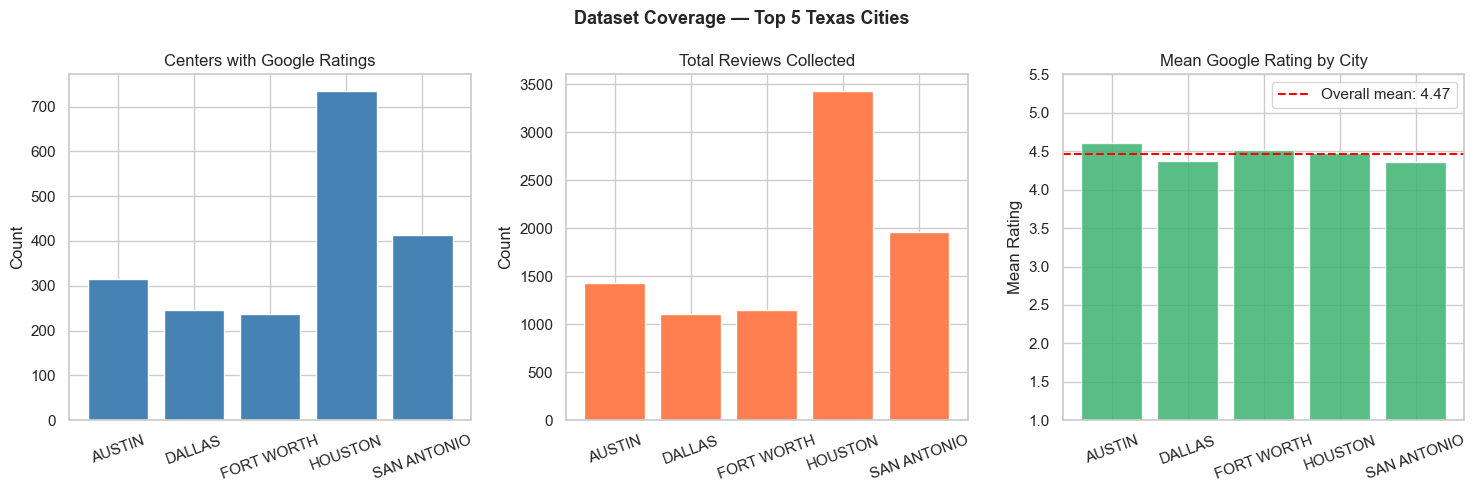

COVERAGE SUMMARY — TOP 5 TEXAS CITIES
HHSC Licensed Centers (5 cities):    2,516
Matched to Google Places:             2,509 (99.7%)
High/medium confidence matches:       2,264
Centers with star ratings:            1,944
Centers with 3+ reviews:              1,804
Total review texts collected:         9,074
Model 1 usable records:               1,944
Model 2 usable records:               1,804


In [17]:
city_summary = df_final.groupby('CITY').agg(
    centers_total      = ('OPERATION_ID', 'count'),
    with_rating        = ('google_rating', lambda x: x.notna().sum()),
    with_3plus_reviews = ('review_count_returned', lambda x: (x >= 3).sum()),
    total_reviews      = ('review_count_returned', 'sum'),
    mean_rating        = ('google_rating', 'mean'),
    median_rating      = ('google_rating', 'median'),
).reset_index()
city_summary['match_rate'] = (city_summary['with_rating'] /
                               city_summary['centers_total'] * 100).round(1)
print(city_summary.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].bar(city_summary['CITY'], city_summary['with_rating'], color='steelblue')
axes[0].set_title('Centers with Google Ratings')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(city_summary['CITY'], city_summary['total_reviews'], color='coral')
axes[1].set_title('Total Reviews Collected')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=20)

axes[2].bar(city_summary['CITY'], city_summary['mean_rating'],
            color='mediumseagreen', alpha=0.85)
overall_mean = df_final['google_rating'].mean()
axes[2].axhline(overall_mean, color='red', linestyle='--',
                label=f'Overall mean: {overall_mean:.2f}')
axes[2].set_ylim(1, 5.5)
axes[2].set_title('Mean Google Rating by City')
axes[2].set_ylabel('Mean Rating')
axes[2].tick_params(axis='x', rotation=20)
axes[2].legend()

plt.suptitle('Dataset Coverage — Top 5 Texas Cities', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'coverage_assessment.png'), dpi=150, bbox_inches='tight')
plt.show()

model1_n      = df_final['google_rating'].notna().sum()
model2_n      = (df_final['review_count_returned'] >= 3).sum()
total_reviews = int(df_final['review_count_returned'].sum())

print("=" * 55)
print("COVERAGE SUMMARY — TOP 5 TEXAS CITIES")
print("=" * 55)
print(f"HHSC Licensed Centers (5 cities):    {len(df):,}")
print(f"Matched to Google Places:             {df['place_id'].notna().sum():,} ({df['place_id'].notna().sum()/len(df)*100:.1f}%)")
print(f"High/medium confidence matches:       {len(df_fetch):,}")
print(f"Centers with star ratings:            {model1_n:,}")
print(f"Centers with 3+ reviews:              {model2_n:,}")
print(f"Total review texts collected:         {total_reviews:,}")
print(f"Model 1 usable records:               {model1_n:,}")
print(f"Model 2 usable records:               {model2_n:,}")
print("=" * 55)

In [ ]:
# ── Checkpoint: save df_final before feature engineering modifies it ─────
# df_final at this point is the output of the two expensive API pipelines:
#   #2 Google Places matching  (~$42, ~13 min)
#   #4 Fetch ratings & reviews (~$35, ~13 min)
# Saving it here means #6 onwards can be re-run without repeating those calls.
#
# Pickle is used (not CSV) because review_texts and review_ratings are Python
# lists — CSV would silently convert them to strings, breaking Section 8.5 and Section 10.

CHECKPOINT_PATH = os.path.join(PROCESSED_DIR, 'df_matched_rated.pkl')
df_final.to_pickle(CHECKPOINT_PATH)

size_mb = os.path.getsize(CHECKPOINT_PATH) / 1024 / 1024
print(f"Checkpoint saved: {CHECKPOINT_PATH}")
print(f"  Shape:     {df_final.shape[0]:,} rows × {df_final.shape[1]} columns")
print(f"  File size: {size_mb:.1f} MB")
print()
print("To reload and skip Section 1–Section 5 on future runs:")
print("  df_final = pd.read_pickle(CHECKPOINT_PATH)")

Checkpoint saved: /Users/rakesh/Documents/CISO/Certifications/UCBMLAI/Capstone/ucbmlai-Capstone-TX-Top5-ChildCare/data/processed/df_matched_rated.pkl
  Shape:     2,468 rows × 55 columns
  File size: 5.3 MB

To reload and skip §1–§5 on future runs:
  df_final = pd.read_pickle(CHECKPOINT_PATH)


In [91]:
# ── Reload checkpoint (skip Sections 1–5 on re-runs) ─────────────────────
# Run Section 0 first, then run this cell, then continue from Section 6.
# This loads df_final from the pickle saved at the end of Section 5,
# bypassing the HHSC download and both Google Places API calls.

CHECKPOINT_PATH = os.path.join(PROCESSED_DIR, 'df_matched_rated.pkl')

if not os.path.exists(CHECKPOINT_PATH):
    raise FileNotFoundError(
        f"Checkpoint not found: {CHECKPOINT_PATH}\n"
        "Run Sections 1–5 once to generate it."
    )

df_final = pd.read_pickle(CHECKPOINT_PATH)
print(f"Loaded checkpoint: {CHECKPOINT_PATH}")
print(f"  Shape: {df_final.shape[0]:,} rows x {df_final.shape[1]} columns")
print(f"  Columns: {list(df_final.columns)}")

Loaded checkpoint: /Users/rakesh/Documents/CISO/Certifications/UCBMLAI/Capstone/ucbmlai-Capstone-TX-Top5-ChildCare/data/processed/df_matched_rated.pkl
  Shape: 2,468 rows x 55 columns
  Columns: ['OPERATION_ID', 'OPERATION_TYPE', 'OPERATION_NUMBER', 'OPERATION_NAME', 'PROGRAMS_PROVIDED', 'LOCATION_ADDRESS', 'MAILING_ADDRESS', 'PHONE_NUMBER', 'COUNTY', 'WEBSITE_ADDRESS', 'ADMINISTRATOR_DIRECTOR_NAME', 'TYPE_OF_ISSUANCE', 'ISSUANCE_DATE', 'CONDITIONS_ON_PERMIT', 'ACCEPTS_CHILD_CARE_SUBSIDIES', 'HOURS_OF_OPERATION', 'DAYS_OF_OPERATION', 'OTHER_SCHEDULE_INFORMATION', 'TOTAL_CAPACITY', 'OPEN_FOSTER_HOMES', 'OPEN_BRANCH_OFFICES', 'LICENSED_TO_SERVE_AGES', 'CORRECTIVE_ACTION', 'ADVERSE_ACTION', 'TEMPORARILY_CLOSED', 'PROGRAMMATIC_SERVICES', 'TREATMENT_SERVICES', 'DEFICIENCY_HIGH', 'DEFICIENCY_MEDIUM_HIGH', 'DEFICIENCY_MEDIUM', 'DEFICIENCY_MEDIUM_LOW', 'DEFICIENCY_LOW', 'TOTAL_INSPECTIONS', 'TOTAL_ASSESSMENTS', 'TOTAL_REPORTS', 'TOTAL_SELF_REPORTS', 'Location_address_geo', 'email_address', 'CA

## 6. Feature Engineering

15 regulatory features are engineered from raw HHSC fields for Model 1.
Feature engineering is applied after Google Places matching so that only centers with confirmed ratings are processed, avoiding wasted computation on unmatched records.

| Category | Features |
|---|---|
| Violation severity | DEFICIENCY_HIGH / MEDIUM_HIGH / MEDIUM / MEDIUM_LOW / LOW |
| Derived rates | TOTAL_DEFICIENCIES, DEFICIENCY_RATE, HIGH_DEFICIENCY_RATE |
| Scale & history | TOTAL_CAPACITY, TOTAL_INSPECTIONS, TOTAL_ASSESSMENTS, YEARS_IN_OPERATION |
| Binary flags | IS_ACCREDITED, ACCEPTS_SUBSIDIES, HAS_CORRECTIVE_ACTION, HAS_ADVERSE_ACTION, WAS_TEMP_CLOSED |

In [92]:
# ── Type casting ──────────────────────────────────────────────────────────
# All columns were loaded as strings (dtype=str). Convert count/capacity
# columns to numeric; errors='coerce' turns unparseable values into NaN
# rather than raising an exception.
numeric_cols = [
    'DEFICIENCY_HIGH', 'DEFICIENCY_MEDIUM_HIGH', 'DEFICIENCY_MEDIUM',
    'DEFICIENCY_MEDIUM_LOW', 'DEFICIENCY_LOW',
    'TOTAL_CAPACITY', 'TOTAL_INSPECTIONS', 'TOTAL_ASSESSMENTS',
    'TOTAL_REPORTS', 'TOTAL_SELF_REPORTS'
]
for col in numeric_cols:
    df_final[col] = pd.to_numeric(df_final[col], errors='coerce')

df_final['ISSUANCE_DATE'] = pd.to_datetime(df_final['ISSUANCE_DATE'], errors='coerce')
# Divide by 365.25 (not 365) to correctly account for leap years
df_final['YEARS_IN_OPERATION'] = ((REFERENCE_DATE - df_final['ISSUANCE_DATE']).dt.days / 365.25).round(1)

# ── Binary flags ──────────────────────────────────────────────────────────
# PROGRAMS_PROVIDED is a free-text field; substring search extracts accreditation status
df_final['IS_ACCREDITED']     = df_final['PROGRAMS_PROVIDED'].str.contains('Accredited', case=False, na=False).astype(int)
# ACCEPTS_CHILD_CARE_SUBSIDIES stores 'Y'/'N'; anything else (blank, unknown) becomes NaN
df_final['ACCEPTS_SUBSIDIES'] = df_final['ACCEPTS_CHILD_CARE_SUBSIDIES'].str.strip().str.upper().map({'Y': 1, 'N': 0})

# HHSC stores 'YES'/'NO' for all centers (never null) — check for 'YES' explicitly.
# HAS_ADVERSE_ACTION and WAS_TEMP_CLOSED are all 'NO' in this dataset (zero variance)
# and are excluded from FEATURE_COLS; computed here for completeness only.
df_final['HAS_CORRECTIVE_ACTION'] = (df_final['CORRECTIVE_ACTION'].str.strip().str.upper() == 'YES').astype(int)
df_final['HAS_ADVERSE_ACTION']    = (df_final['ADVERSE_ACTION'].str.strip().str.upper() == 'YES').astype(int)
df_final['WAS_TEMP_CLOSED']       = (df_final['TEMPORARILY_CLOSED'].str.strip().str.upper() == 'YES').astype(int)

# ── Derived rate features ─────────────────────────────────────────────────
# fillna(0) treats missing severity tiers as zero violations
df_final['TOTAL_DEFICIENCIES'] = (
    df_final['DEFICIENCY_HIGH'].fillna(0) + df_final['DEFICIENCY_MEDIUM_HIGH'].fillna(0) +
    df_final['DEFICIENCY_MEDIUM'].fillna(0) + df_final['DEFICIENCY_MEDIUM_LOW'].fillna(0) +
    df_final['DEFICIENCY_LOW'].fillna(0)
)
# replace(0, np.nan) on the denominator prevents division-by-zero producing inf
df_final['DEFICIENCY_RATE']      = (df_final['TOTAL_DEFICIENCIES'] /
                                     df_final['TOTAL_INSPECTIONS'].replace(0, np.nan)).round(3)
df_final['HIGH_DEFICIENCY_RATE'] = (df_final['DEFICIENCY_HIGH'].fillna(0) /
                                     df_final['TOTAL_INSPECTIONS'].replace(0, np.nan)).round(3)

# ── df_final summary ──────────────────────────────────────────────────────
# Quality filters (TOTAL_INSPECTIONS, TOTAL_CAPACITY, ISSUANCE_DATE) are applied
# in Section 9.1 to df_m1 only — keeping df_final intact for Model 2 review text.
print("=" * 55)
print("df_final — POST FEATURE ENGINEERING SUMMARY")
print("=" * 55)
print(f"Shape: {df_final.shape[0]:,} rows × {df_final.shape[1]} columns")
print()

print("── Columns & dtypes ─────────────────────────────────")
print(df_final.dtypes.to_string())
print()

print("── Records by city ──────────────────────────────────")
print(df_final['CITY'].value_counts().to_string())
print()

print("── Model eligibility ────────────────────────────────")
print(f"  With google_rating (Model 1 candidates): {df_final['google_rating'].notna().sum():,}")
print(f"  With 1+ reviews   (Model 2 candidates): {(df_final['review_count_returned'] >= 1).sum():,}")
print(f"  With 3+ reviews   (Model 2 preferred):  {(df_final['review_count_returned'] >= 3).sum():,}")
print()

print("── Binary flag prevalence (post-fix) ────────────────")
for col in ['IS_ACCREDITED','ACCEPTS_SUBSIDIES','HAS_CORRECTIVE_ACTION','HAS_ADVERSE_ACTION','WAS_TEMP_CLOSED']:
    n = df_final[col].sum()
    print(f"  {col:<25} {n:>4} / {len(df_final):,}  ({n/len(df_final)*100:.1f}%)")
print()

print("── Missing values (all columns) ─────────────────────")
missing_all = df_final.isnull().sum()
missing_all = missing_all[missing_all > 0].sort_values(ascending=False)
print(missing_all.to_string() if len(missing_all) else "  None")
print()

print("── Engineered feature stats ─────────────────────────")
print(df_final[FEATURE_COLS].describe().round(2).to_string())
print("=" * 55)

df_final — POST FEATURE ENGINEERING SUMMARY
Shape: 2,468 rows × 64 columns

── Columns & dtypes ─────────────────────────────────
OPERATION_ID                            object
OPERATION_TYPE                          object
OPERATION_NUMBER                        object
OPERATION_NAME                          object
PROGRAMS_PROVIDED                       object
LOCATION_ADDRESS                        object
MAILING_ADDRESS                         object
PHONE_NUMBER                            object
COUNTY                                  object
WEBSITE_ADDRESS                         object
ADMINISTRATOR_DIRECTOR_NAME             object
TYPE_OF_ISSUANCE                        object
ISSUANCE_DATE                   datetime64[ns]
CONDITIONS_ON_PERMIT                    object
ACCEPTS_CHILD_CARE_SUBSIDIES            object
HOURS_OF_OPERATION                      object
DAYS_OF_OPERATION                       object
OTHER_SCHEDULE_INFORMATION              object
TOTAL_CAPACITY          

## 7. Data Overview & Cleaning

The engineered feature set is inspected for missing values and imputation is applied before EDA and modelling.

In [93]:
print(f"Dataset shape: {df_final.shape}")
print()
print("Missing values in regulatory features:")
missing = df_final[FEATURE_COLS].isnull().sum()
missing_nonzero = missing[missing > 0]
if len(missing_nonzero):
    print(missing_nonzero.to_string())
else:
    print("  None")
print()
df_final[FEATURE_COLS].describe().round(2)

Dataset shape: (2468, 64)

Missing values in regulatory features:
  None



,DEFICIENCY_HIGH,DEFICIENCY_MEDIUM_HIGH,DEFICIENCY_MEDIUM,DEFICIENCY_MEDIUM_LOW,DEFICIENCY_LOW,TOTAL_DEFICIENCIES,DEFICIENCY_RATE,HIGH_DEFICIENCY_RATE,TOTAL_CAPACITY,TOTAL_INSPECTIONS,TOTAL_ASSESSMENTS,YEARS_IN_OPERATION,IS_ACCREDITED,ACCEPTS_SUBSIDIES,HAS_CORRECTIVE_ACTION,HAS_ADVERSE_ACTION,WAS_TEMP_CLOSED
count,2468.00,2468.00,2468.00,2468.00,2468.00,2468.00,2468.00,2468.00,2468.00,2468.00,2468.00,2468.00,2468.00,2468.00,2468.00,2468.0,2468.0
mean,3.09,5.43,3.35,0.48,0.17,12.53,1.03,0.22,117.46,11.47,0.39,12.84,0.14,0.56,0.01,0.0,0.0
std,4.19,6.46,4.08,0.93,0.48,13.86,0.88,0.22,80.76,7.23,0.84,11.98,0.34,0.50,0.07,0.0,0.0
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,8.00,1.00,0.00,-0.30,0.00,0.00,0.00,0.0,0.0
25%,0.00,1.00,1.00,0.00,0.00,3.00,0.40,0.00,63.00,7.00,0.00,3.20,0.00,0.00,0.00,0.0,0.0
50%,2.00,3.00,2.00,0.00,0.00,8.00,0.83,0.18,100.00,10.00,0.00,8.65,0.00,1.00,0.00,0.0,0.0
75%,4.00,7.00,5.00,1.00,0.00,17.00,1.43,0.33,150.00,14.00,1.00,19.90,0.00,1.00,0.00,0.0,0.0
max,35.00,57.00,41.00,8.00,6.00,129.00,9.00,1.50,999.00,64.00,11.00,40.40,1.00,1.00,1.00,0.0,0.0


In [94]:
# ── Imputation ────────────────────────────────────────────────────────────
# ACCEPTS_SUBSIDIES: map failures → 0 (conservative: assume no subsidy acceptance)
df_final['ACCEPTS_SUBSIDIES'] = df_final['ACCEPTS_SUBSIDIES'].fillna(0).astype(int)

# Rates: NaN arises when TOTAL_INSPECTIONS == 0 after filter; safe to fill with 0
df_final['DEFICIENCY_RATE']      = df_final['DEFICIENCY_RATE'].fillna(0)
df_final['HIGH_DEFICIENCY_RATE'] = df_final['HIGH_DEFICIENCY_RATE'].fillna(0)

# TOTAL_ASSESSMENTS: not all centers have formal assessments; NaN → 0
df_final['TOTAL_ASSESSMENTS'] = df_final['TOTAL_ASSESSMENTS'].fillna(0)

# YEARS_IN_OPERATION: clip negatives (data entry errors in ISSUANCE_DATE)
df_final['YEARS_IN_OPERATION'] = df_final['YEARS_IN_OPERATION'].clip(lower=0)

# Duplicate check
dupes = df_final['OPERATION_ID'].duplicated().sum()
print(f"Duplicate OPERATION_IDs: {dupes}")

print()
print("Missing values after imputation:")
missing_after = df_final[FEATURE_COLS].isnull().sum()
missing_after_nz = missing_after[missing_after > 0]
if len(missing_after_nz):
    print(missing_after_nz.to_string())
else:
    print("  None — all features complete")
print()
print("Data cleaning complete.")

Duplicate OPERATION_IDs: 204

Missing values after imputation:
  None — all features complete

Data cleaning complete.


In [95]:
# ── Column datatypes before export ───────────────────────────────────────
print(f"df_final: {df_final.shape[0]:,} rows x {df_final.shape[1]} columns")
print()
print(f"{'Column':<40} {'Dtype':<15} {'Non-Null':>10} {'Null':>8}")
print("-" * 78)
for col in df_final.columns:
    dtype   = str(df_final[col].dtype)
    non_null = df_final[col].notna().sum()
    null    = df_final[col].isna().sum()
    print(f"{col:<40} {dtype:<15} {non_null:>10,} {null:>8,}")


df_final: 2,468 rows x 64 columns

Column                                   Dtype             Non-Null     Null
------------------------------------------------------------------------------
OPERATION_ID                             object               2,468        0
OPERATION_TYPE                           object               2,468        0
OPERATION_NUMBER                         object               2,468        0
OPERATION_NAME                           object               2,468        0
PROGRAMS_PROVIDED                        object               2,417       51
LOCATION_ADDRESS                         object               2,468        0
MAILING_ADDRESS                          object               2,468        0
PHONE_NUMBER                             object               2,466        2
COUNTY                                   object               2,468        0
WEBSITE_ADDRESS                          object               1,470      998
ADMINISTRATOR_DIRECTOR_NAME            

In [96]:
# ── Export cleaned dataset ────────────────────────────────────────────────
# Saved as pickle to preserve all dtypes — list columns (review_texts,
# review_ratings) are not representable in CSV and would silently corrupt.
# A CSV copy is also saved with list columns dropped for easy inspection.

CLEANED_PKL = os.path.join(PROCESSED_DIR, 'df_cleaned.pkl')
CLEANED_CSV = os.path.join(PROCESSED_DIR, 'df_cleaned.csv')

df_final.to_pickle(CLEANED_PKL)

# Drop list columns before writing CSV — they contain Python lists
list_cols   = [c for c in df_final.columns if df_final[c].apply(type).eq(list).any()]
df_final.drop(columns=list_cols).to_csv(CLEANED_CSV, index=False)

pkl_mb = os.path.getsize(CLEANED_PKL) / 1024 / 1024
csv_mb = os.path.getsize(CLEANED_CSV) / 1024 / 1024

print(f"Cleaned dataset exported:")
print(f"  {CLEANED_PKL}  ({pkl_mb:.1f} MB)  ← full dataset including review lists")
print(f"  {CLEANED_CSV}  ({csv_mb:.1f} MB)  ← flat CSV, list columns excluded: {list_cols}")
print()
print(f"Shape: {df_final.shape[0]:,} rows × {df_final.shape[1]} columns")

Cleaned dataset exported:
  /Users/rakesh/Documents/CISO/Certifications/UCBMLAI/Capstone/ucbmlai-Capstone-TX-Top5-ChildCare/data/processed/df_cleaned.pkl  (5.6 MB)  ← full dataset including review lists
  /Users/rakesh/Documents/CISO/Certifications/UCBMLAI/Capstone/ucbmlai-Capstone-TX-Top5-ChildCare/data/processed/df_cleaned.csv  (1.7 MB)  ← flat CSV, list columns excluded: ['review_texts', 'review_ratings']

Shape: 2,468 rows × 64 columns


## 8. Exploratory Data Analysis

Before building any model, the data is explored to understand its structure, spot potential problems, and make informed decisions about how to prepare it for machine learning. The EDA is organised into seven subsections, each with a specific purpose.

| Subsection | What is Examined | Purpose |
|---|---|---|
| 8.1 Target Variable | Distribution of Google star ratings across all centers and cities | To understand what the model is predicting before choosing a metric or interpreting results |
| 8.2 Regulatory Feature Distributions | Distribution of each of the 15 engineered features | To identify features that are heavily skewed, dominated by zeros, or have very different scales |
| 8.3 Feature Correlations | Linear relationship between each regulatory feature and the Google rating, and between features themselves | To find which features are most likely to be useful predictors and whether any features are so similar that they may cause issues during modelling |
| 8.4 Scatter Plots | Relationship between four key regulatory features and Google rating, broken down by city | To visualise whether any single feature separates high-rated centers from low-rated ones and whether the pattern holds across cities |
| 8.5 Outlier Analysis | Extreme values in each continuous feature using the IQR method | To determine whether extreme values are data errors that should be removed or legitimate observations that should be kept |
| 8.6 Review Text Overview | Volume, length, and rating distribution of the review text corpus | To confirm the coverage and quality of the text data that will be used for Model 2 in Module 24 |
| 8.7 EDA Summary | Findings from all subsections combined | To draw conclusions that directly inform the modelling decisions in Section 9 |


### 8.1 Target Variable — Google Star Rating

The distribution of Google star ratings is examined across all centers and broken down by city.

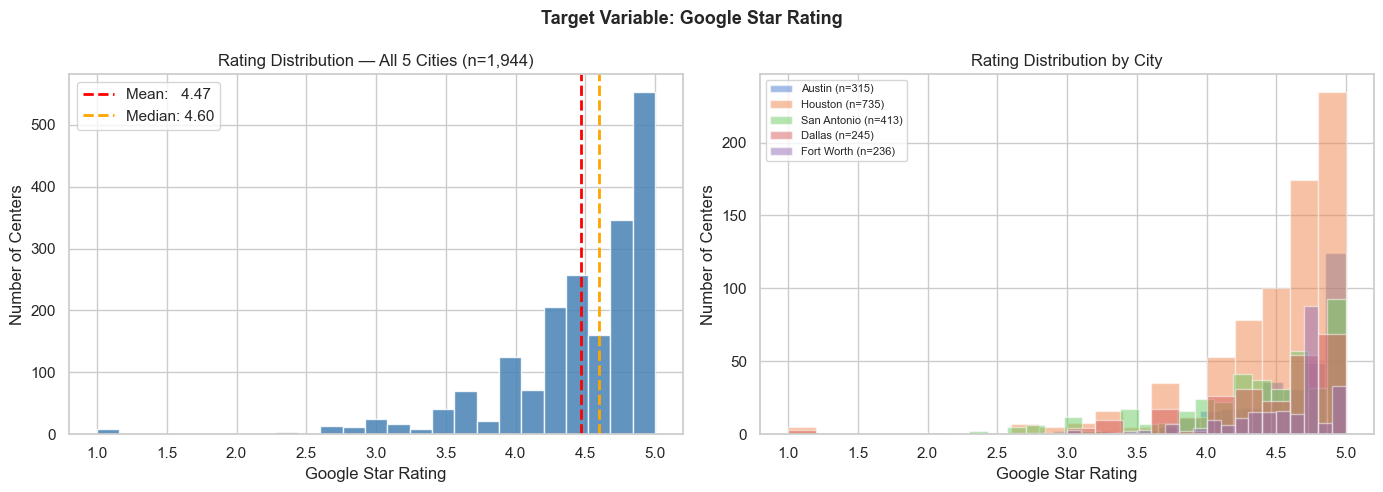

Count:  1,944
Mean:   4.466
Median: 4.60
Std:    0.573
Min / Max: 1.0 / 5.0

Rating Band   Centers       %
------------------------------
1.0 – 2.0          10    0.5%
2.0 – 3.0          31    1.6%
3.0 – 3.5          73    3.8%
3.5 – 4.0         143    7.4%
4.0 – 4.5         491   25.3%
4.5 – 5.0       1,196   61.5%


In [97]:
ratings = df_final['google_rating'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(ratings, bins=25, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(ratings.mean(),   color='red',    linestyle='--', linewidth=2,
                label=f'Mean:   {ratings.mean():.2f}')
axes[0].axvline(ratings.median(), color='orange', linestyle='--', linewidth=2,
                label=f'Median: {ratings.median():.2f}')
axes[0].set_xlabel('Google Star Rating')
axes[0].set_ylabel('Number of Centers')
axes[0].set_title(f'Rating Distribution — All 5 Cities (n={len(ratings):,})')
axes[0].legend()

for city in TARGET_CITIES:
    subset = df_final[df_final['CITY'] == city]['google_rating'].dropna()
    if len(subset):
        axes[1].hist(subset, bins=20, alpha=0.5, label=f'{city.title()} (n={len(subset)})')
axes[1].set_xlabel('Google Star Rating')
axes[1].set_ylabel('Number of Centers')
axes[1].set_title('Rating Distribution by City')
axes[1].legend(fontsize=8)

plt.suptitle('Target Variable: Google Star Rating', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'eda_8_1_target_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Count:  {len(ratings):,}")
print(f"Mean:   {ratings.mean():.3f}")
print(f"Median: {ratings.median():.2f}")
print(f"Std:    {ratings.std():.3f}")
print(f"Min / Max: {ratings.min():.1f} / {ratings.max():.1f}")
bands = [
    ("1.0 – 2.0", (ratings >= 1.0) & (ratings <  2.0)),
    ("2.0 – 3.0", (ratings >= 2.0) & (ratings <  3.0)),
    ("3.0 – 3.5", (ratings >= 3.0) & (ratings <  3.5)),
    ("3.5 – 4.0", (ratings >= 3.5) & (ratings <  4.0)),
    ("4.0 – 4.5", (ratings >= 4.0) & (ratings <  4.5)),
    ("4.5 – 5.0", (ratings >= 4.5) & (ratings <= 5.0)),
]
print(f"\n{'Rating Band':<12} {'Centers':>8} {'%':>7}")
print("-" * 30)
for label, mask in bands:
    n = mask.sum()
    print(f"{label:<12} {n:>8,} {n/len(ratings)*100:>6.1f}%")

### 8.2 Regulatory Feature Distributions

The distribution of all 15 regulatory features is examined to understand scale, skew, and zero-inflation before modelling.

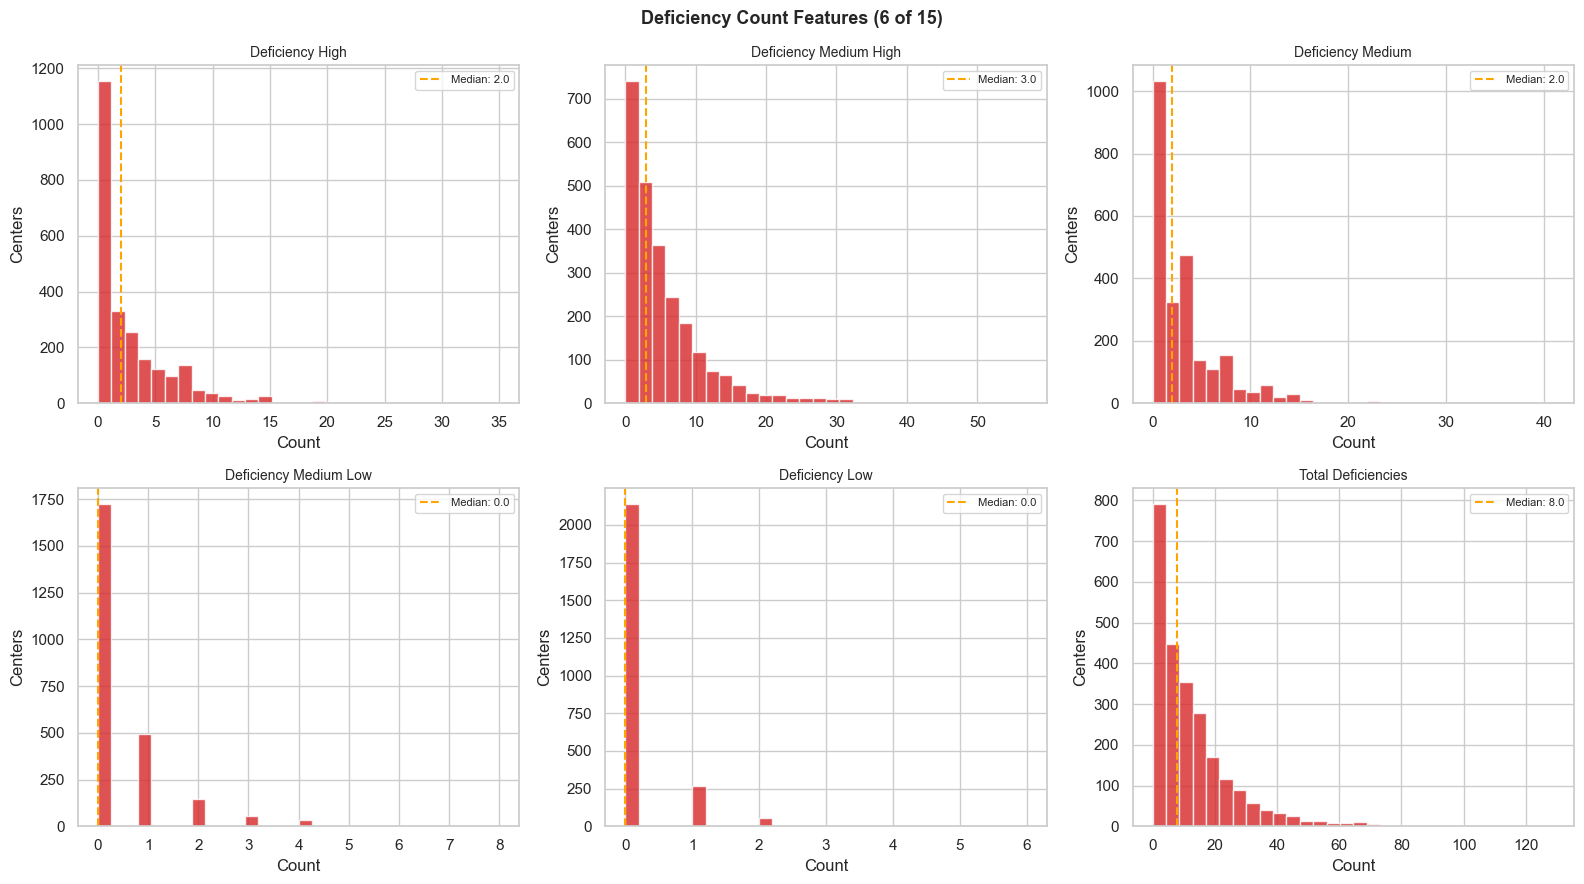

In [98]:
# Raw deficiency count features — how many violations of each severity tier
deficiency_counts = [
    'DEFICIENCY_HIGH', 'DEFICIENCY_MEDIUM_HIGH', 'DEFICIENCY_MEDIUM',
    'DEFICIENCY_MEDIUM_LOW', 'DEFICIENCY_LOW', 'TOTAL_DEFICIENCIES'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, col in zip(axes, deficiency_counts):
    data = df_final[col].dropna()
    ax.hist(data, bins=30, color='#d62728', edgecolor='white', alpha=0.8)
    ax.axvline(data.median(), color='orange', linestyle='--', linewidth=1.5,
               label=f'Median: {data.median():.1f}')
    ax.set_title(col.replace('_', ' ').title(), fontsize=10)
    ax.set_xlabel('Count')
    ax.set_ylabel('Centers')
    ax.legend(fontsize=8)

plt.suptitle('Deficiency Count Features (6 of 15)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'eda_8_2_deficiency_counts.png'), dpi=150, bbox_inches='tight')
plt.show()


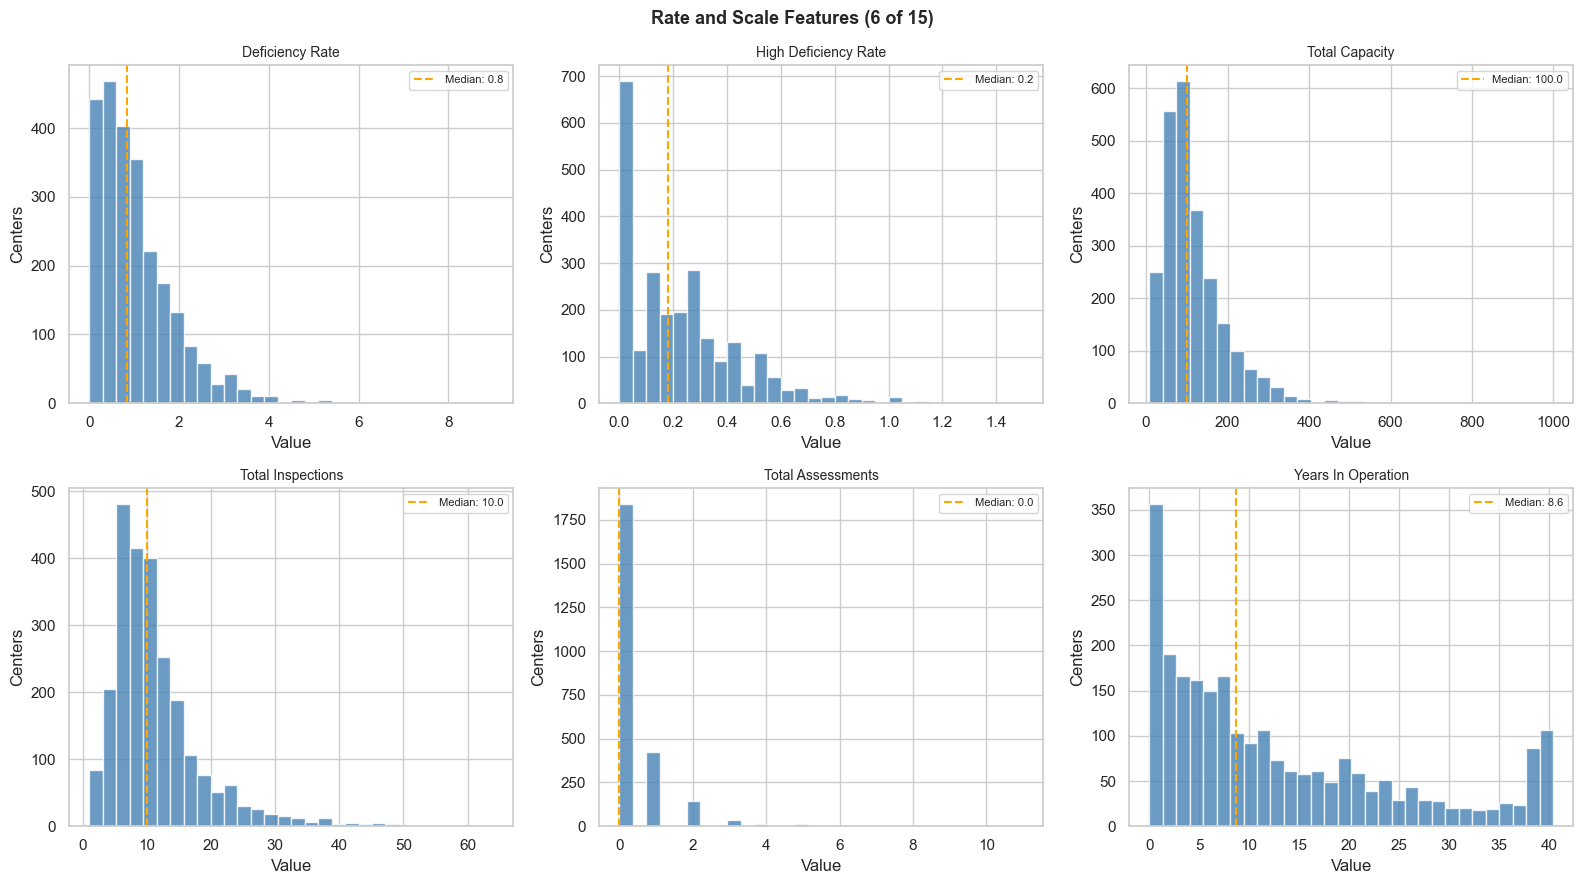

In [99]:
# Rate and scale features — normalised rates, size, and operational history
rate_scale = [
    'DEFICIENCY_RATE', 'HIGH_DEFICIENCY_RATE', 'TOTAL_CAPACITY',
    'TOTAL_INSPECTIONS', 'TOTAL_ASSESSMENTS', 'YEARS_IN_OPERATION'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, col in zip(axes, rate_scale):
    data = df_final[col].dropna()
    ax.hist(data, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(data.median(), color='orange', linestyle='--', linewidth=1.5,
               label=f'Median: {data.median():.1f}')
    ax.set_title(col.replace('_', ' ').title(), fontsize=10)
    ax.set_xlabel('Value')
    ax.set_ylabel('Centers')
    ax.legend(fontsize=8)

plt.suptitle('Rate and Scale Features (6 of 15)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'eda_8_2_rate_scale_features.png'), dpi=150, bbox_inches='tight')
plt.show()


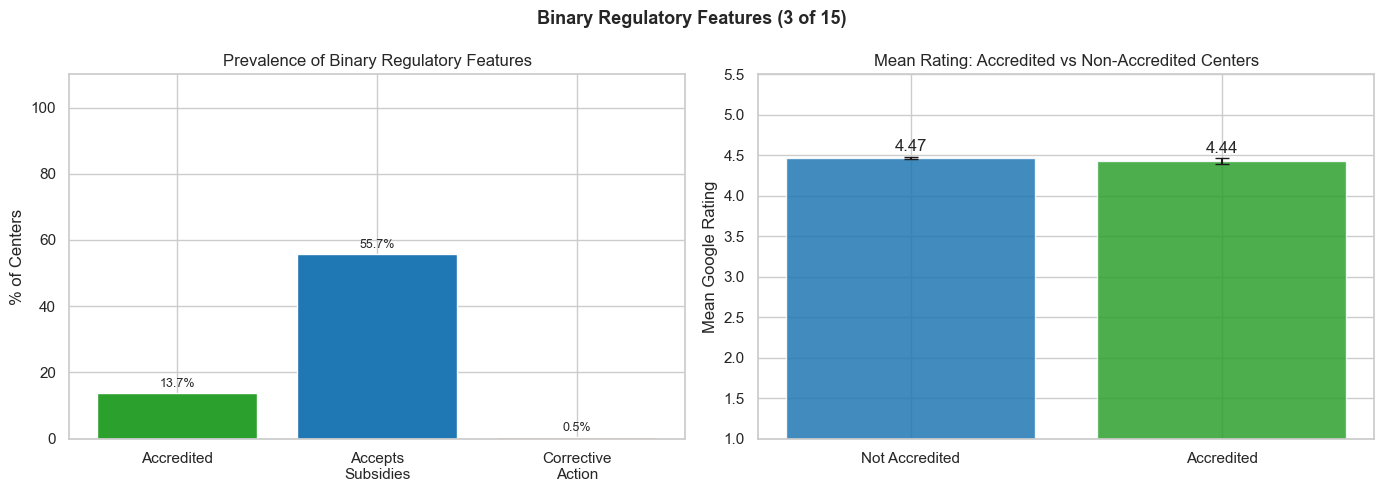

In [100]:
# Binary features — three flags used in modelling
# HAS_ADVERSE_ACTION and WAS_TEMP_CLOSED excluded: zero variance in the 5-city active dataset
binary_features = ['IS_ACCREDITED', 'ACCEPTS_SUBSIDIES', 'HAS_CORRECTIVE_ACTION']
labels = ['Accredited', 'Accepts\nSubsidies', 'Corrective\nAction']
colors_bin = ['#2ca02c', '#1f77b4', '#ff7f0e']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pcts = [df_final[f].sum() / len(df_final) * 100 for f in binary_features]
bars = axes[0].bar(labels, pcts, color=colors_bin)
axes[0].set_ylabel('% of Centers')
axes[0].set_title('Prevalence of Binary Regulatory Features')
axes[0].set_ylim(0, 110)
for bar, pct in zip(bars, pcts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

acc = df_final.groupby('IS_ACCREDITED')['google_rating'].agg(['mean', 'sem']).reset_index()
acc['label'] = acc['IS_ACCREDITED'].map({0: 'Not Accredited', 1: 'Accredited'})
axes[1].bar(acc['label'], acc['mean'], yerr=acc['sem'], capsize=5,
            color=['#1f77b4', '#2ca02c'], alpha=0.85)
axes[1].set_ylim(1, 5.5)
axes[1].set_ylabel('Mean Google Rating')
axes[1].set_title('Mean Rating: Accredited vs Non-Accredited Centers')
for i, row in acc.iterrows():
    axes[1].text(i, row['mean'] + 0.05, f"{row['mean']:.2f}", ha='center', va='bottom')

plt.suptitle('Binary Regulatory Features (3 of 15)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'eda_8_2_binary_features.png'), dpi=150, bbox_inches='tight')
plt.show()


### 8.3 Feature Correlations with Google Rating

The correlation between each of the 15 regulatory features and Google star rating is examined, along with pairwise correlations between features, to identify potential predictors and multicollinearity.

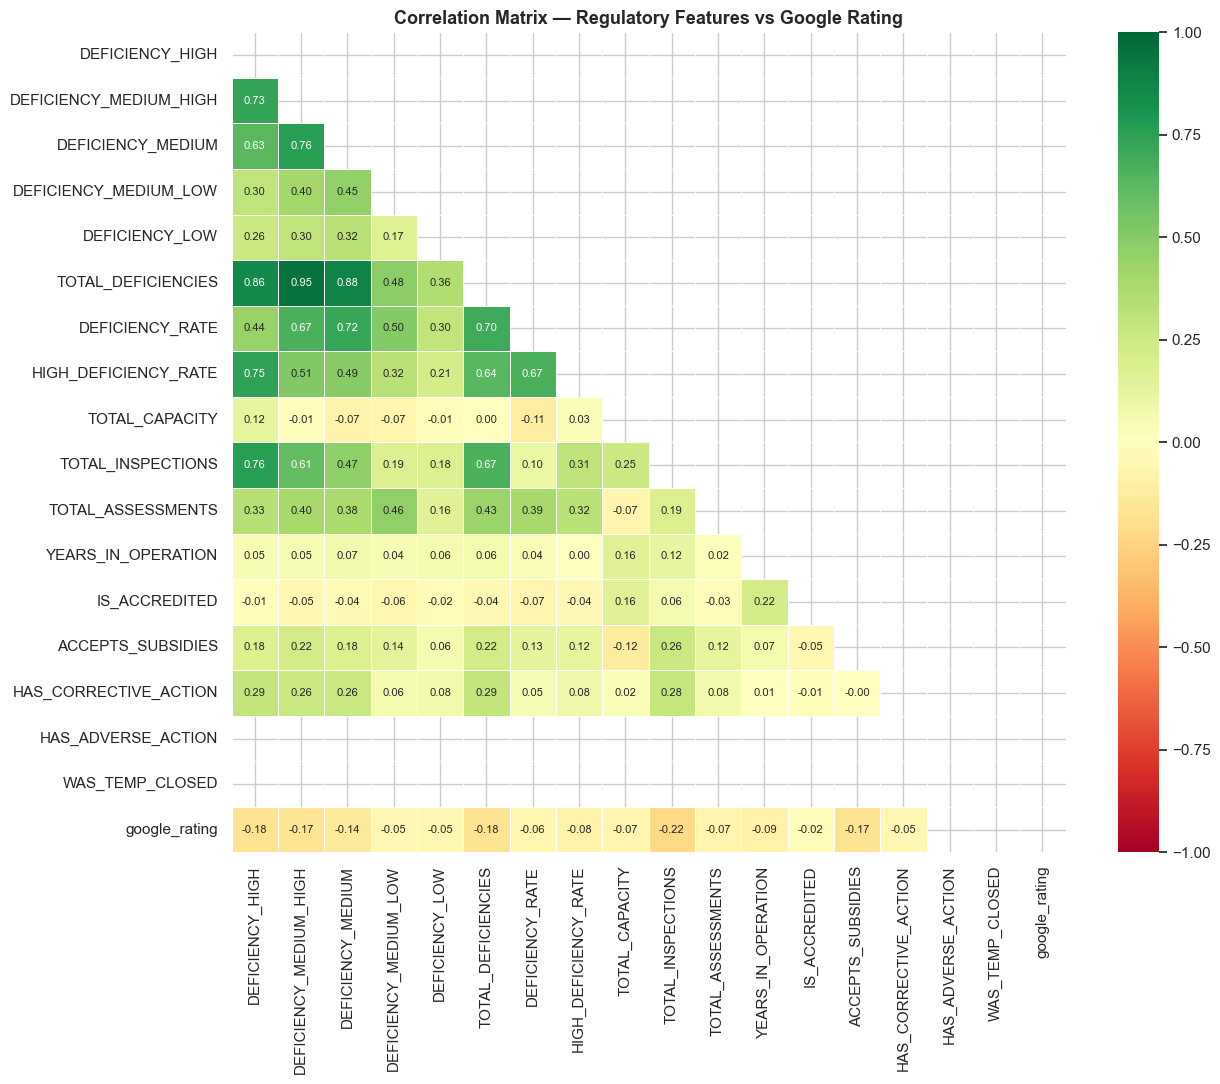

Feature correlations with Google Rating (sorted):
TOTAL_INSPECTIONS        -0.223
TOTAL_DEFICIENCIES       -0.178
DEFICIENCY_HIGH          -0.177
ACCEPTS_SUBSIDIES        -0.175
DEFICIENCY_MEDIUM_HIGH   -0.169
DEFICIENCY_MEDIUM        -0.140
YEARS_IN_OPERATION       -0.090
HIGH_DEFICIENCY_RATE     -0.078
TOTAL_ASSESSMENTS        -0.068
TOTAL_CAPACITY           -0.067
DEFICIENCY_RATE          -0.059
DEFICIENCY_LOW           -0.050
HAS_CORRECTIVE_ACTION    -0.048
DEFICIENCY_MEDIUM_LOW    -0.045
IS_ACCREDITED            -0.021
HAS_ADVERSE_ACTION          NaN
WAS_TEMP_CLOSED             NaN


In [101]:
corr_cols   = FEATURE_COLS + ['google_rating']
corr_df     = df_final[corr_cols].dropna(subset=['google_rating'])
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            annot_kws={"size": 8})
ax.set_title('Correlation Matrix — Regulatory Features vs Google Rating',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'eda_8_3_correlation_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

print("Feature correlations with Google Rating (sorted):")
print(corr_matrix['google_rating'].drop('google_rating').sort_values().round(3).to_string())

### 8.4 Scatter Plots: Regulatory Features vs Google Rating

All 12 continuous regulatory features are plotted against Google star rating, coloured by city, to show whether any feature separates high-rated centers from low-rated ones and whether any pattern holds consistently across geographies. Binary features are excluded as 0/1 values do not produce meaningful scatter plots.

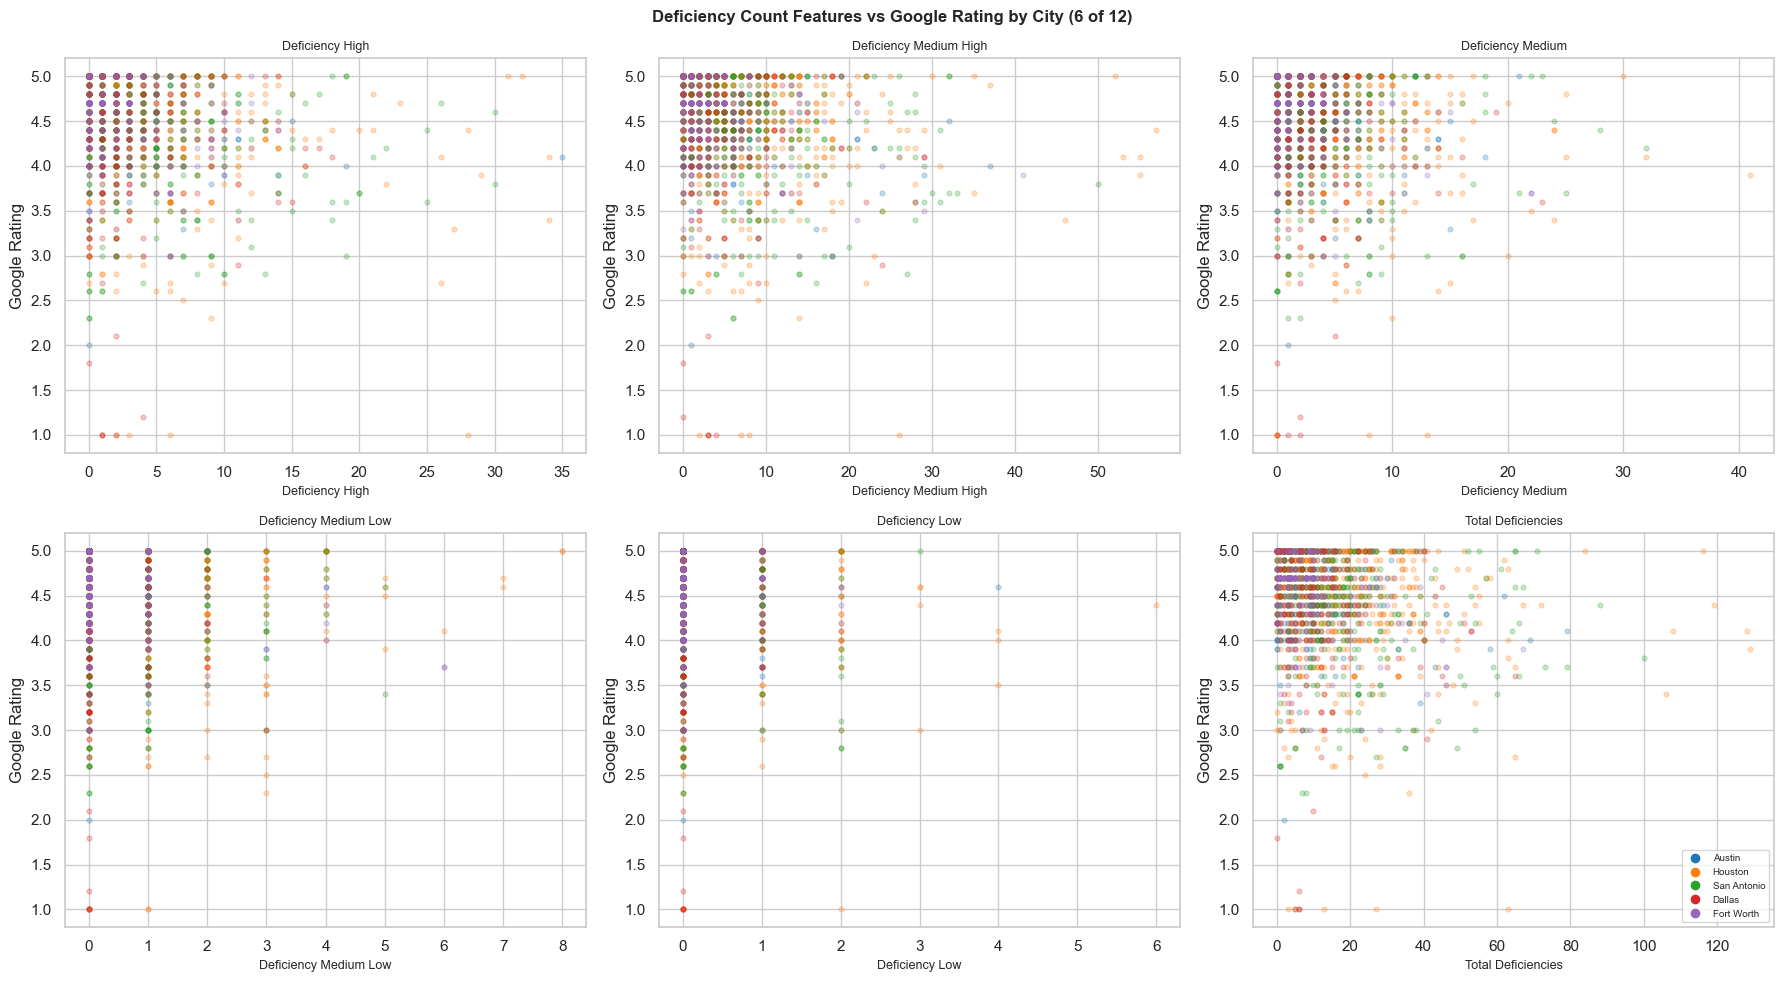

In [102]:
scatter_group = ['DEFICIENCY_HIGH', 'DEFICIENCY_MEDIUM_HIGH', 'DEFICIENCY_MEDIUM', 'DEFICIENCY_MEDIUM_LOW', 'DEFICIENCY_LOW', 'TOTAL_DEFICIENCIES']
plot_df = df_final[scatter_group + ['google_rating', 'CITY']].dropna(subset=['google_rating'])

city_colors = dict(zip(TARGET_CITIES,
                       ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd']))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, scatter_group):
    for city in TARGET_CITIES:
        sub = plot_df[plot_df['CITY'] == city]
        ax.scatter(sub[col], sub['google_rating'],
                   alpha=0.25, s=12, color=city_colors[city], label=city.title())
    ax.set_xlabel(col.replace('_', ' ').title(), fontsize=9)
    ax.set_ylabel('Google Rating')
    ax.set_title(col.replace('_', ' ').title(), fontsize=9)

handles = [plt.Line2D([0],[0], marker='o', color='w',
           markerfacecolor=city_colors[c], markersize=8, label=c.title())
           for c in TARGET_CITIES]
axes[-1].legend(handles=handles, fontsize=7, loc='lower right')

plt.suptitle('Deficiency Count Features vs Google Rating by City (6 of 12)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'eda_8_4_scatter_deficiency_counts.png'), dpi=150, bbox_inches='tight')
plt.show()


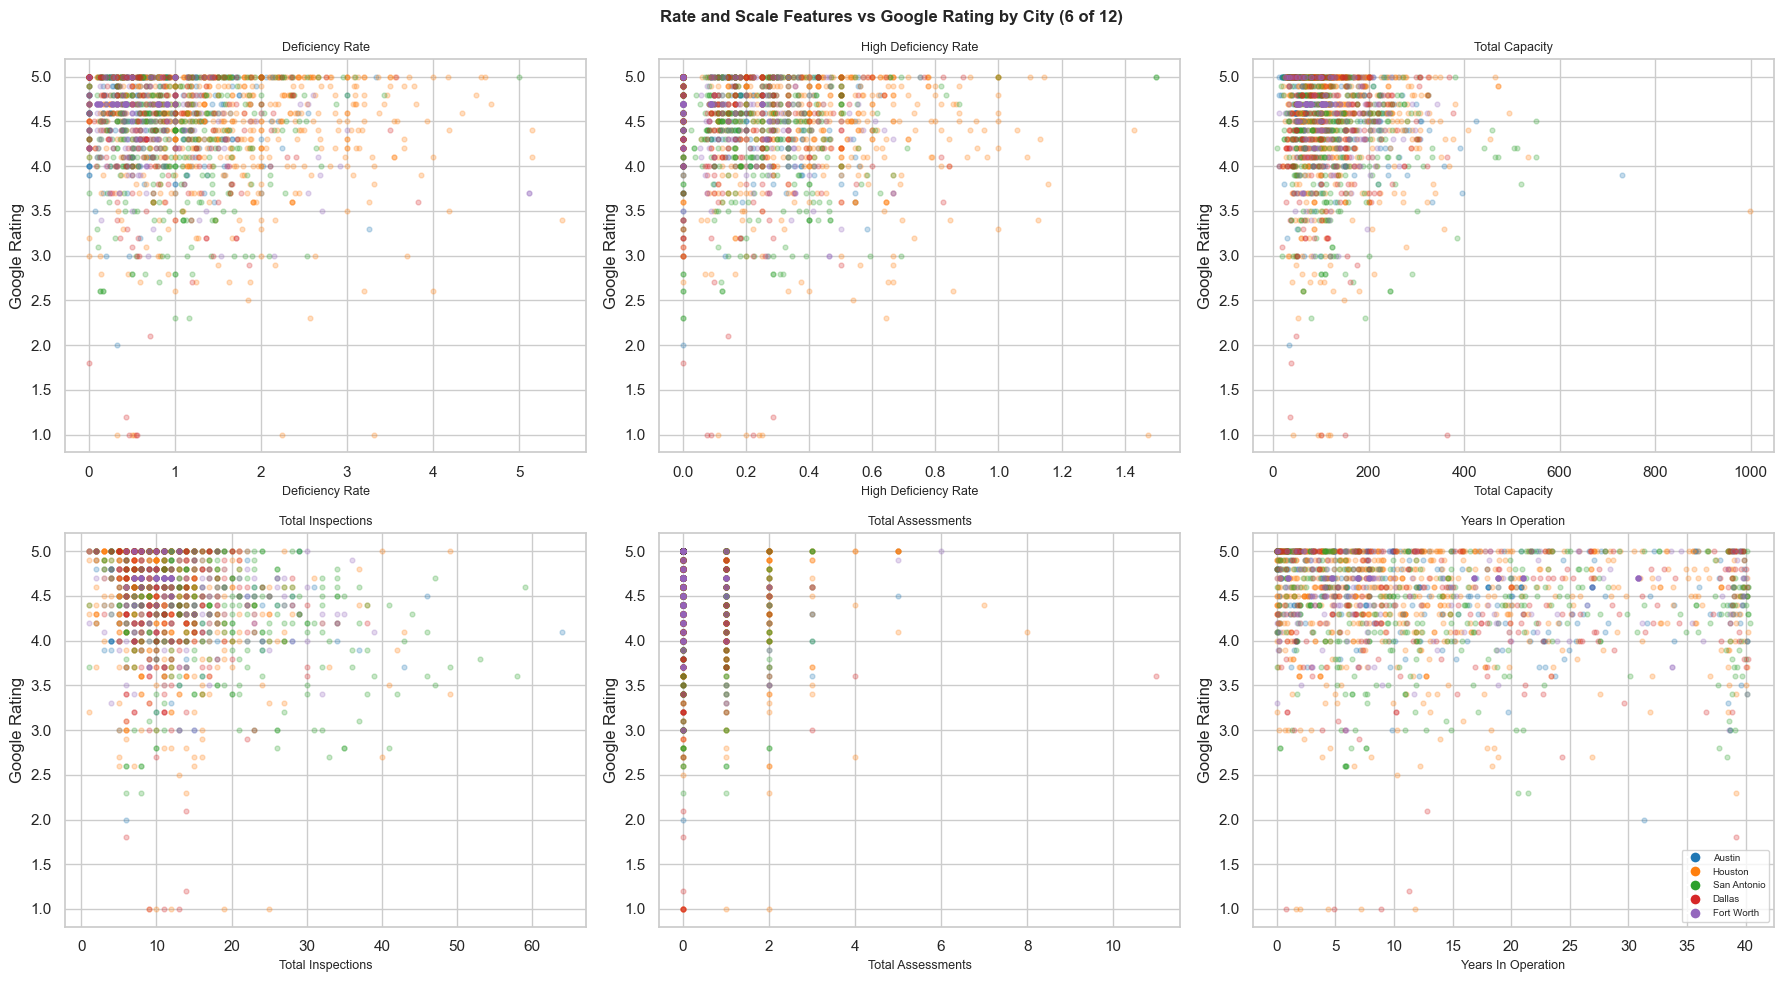

In [103]:
scatter_group = ['DEFICIENCY_RATE', 'HIGH_DEFICIENCY_RATE', 'TOTAL_CAPACITY', 'TOTAL_INSPECTIONS', 'TOTAL_ASSESSMENTS', 'YEARS_IN_OPERATION']
plot_df = df_final[scatter_group + ['google_rating', 'CITY']].dropna(subset=['google_rating'])

city_colors = dict(zip(TARGET_CITIES,
                       ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd']))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, scatter_group):
    for city in TARGET_CITIES:
        sub = plot_df[plot_df['CITY'] == city]
        ax.scatter(sub[col], sub['google_rating'],
                   alpha=0.25, s=12, color=city_colors[city], label=city.title())
    ax.set_xlabel(col.replace('_', ' ').title(), fontsize=9)
    ax.set_ylabel('Google Rating')
    ax.set_title(col.replace('_', ' ').title(), fontsize=9)

handles = [plt.Line2D([0],[0], marker='o', color='w',
           markerfacecolor=city_colors[c], markersize=8, label=c.title())
           for c in TARGET_CITIES]
axes[-1].legend(handles=handles, fontsize=7, loc='lower right')

plt.suptitle('Rate and Scale Features vs Google Rating by City (6 of 12)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'eda_8_4_scatter_rate_scale.png'), dpi=150, bbox_inches='tight')
plt.show()


### 8.5 Outlier Analysis

Extreme values in each continuous feature are identified using the IQR method to determine whether they represent data errors or legitimate operational variation.

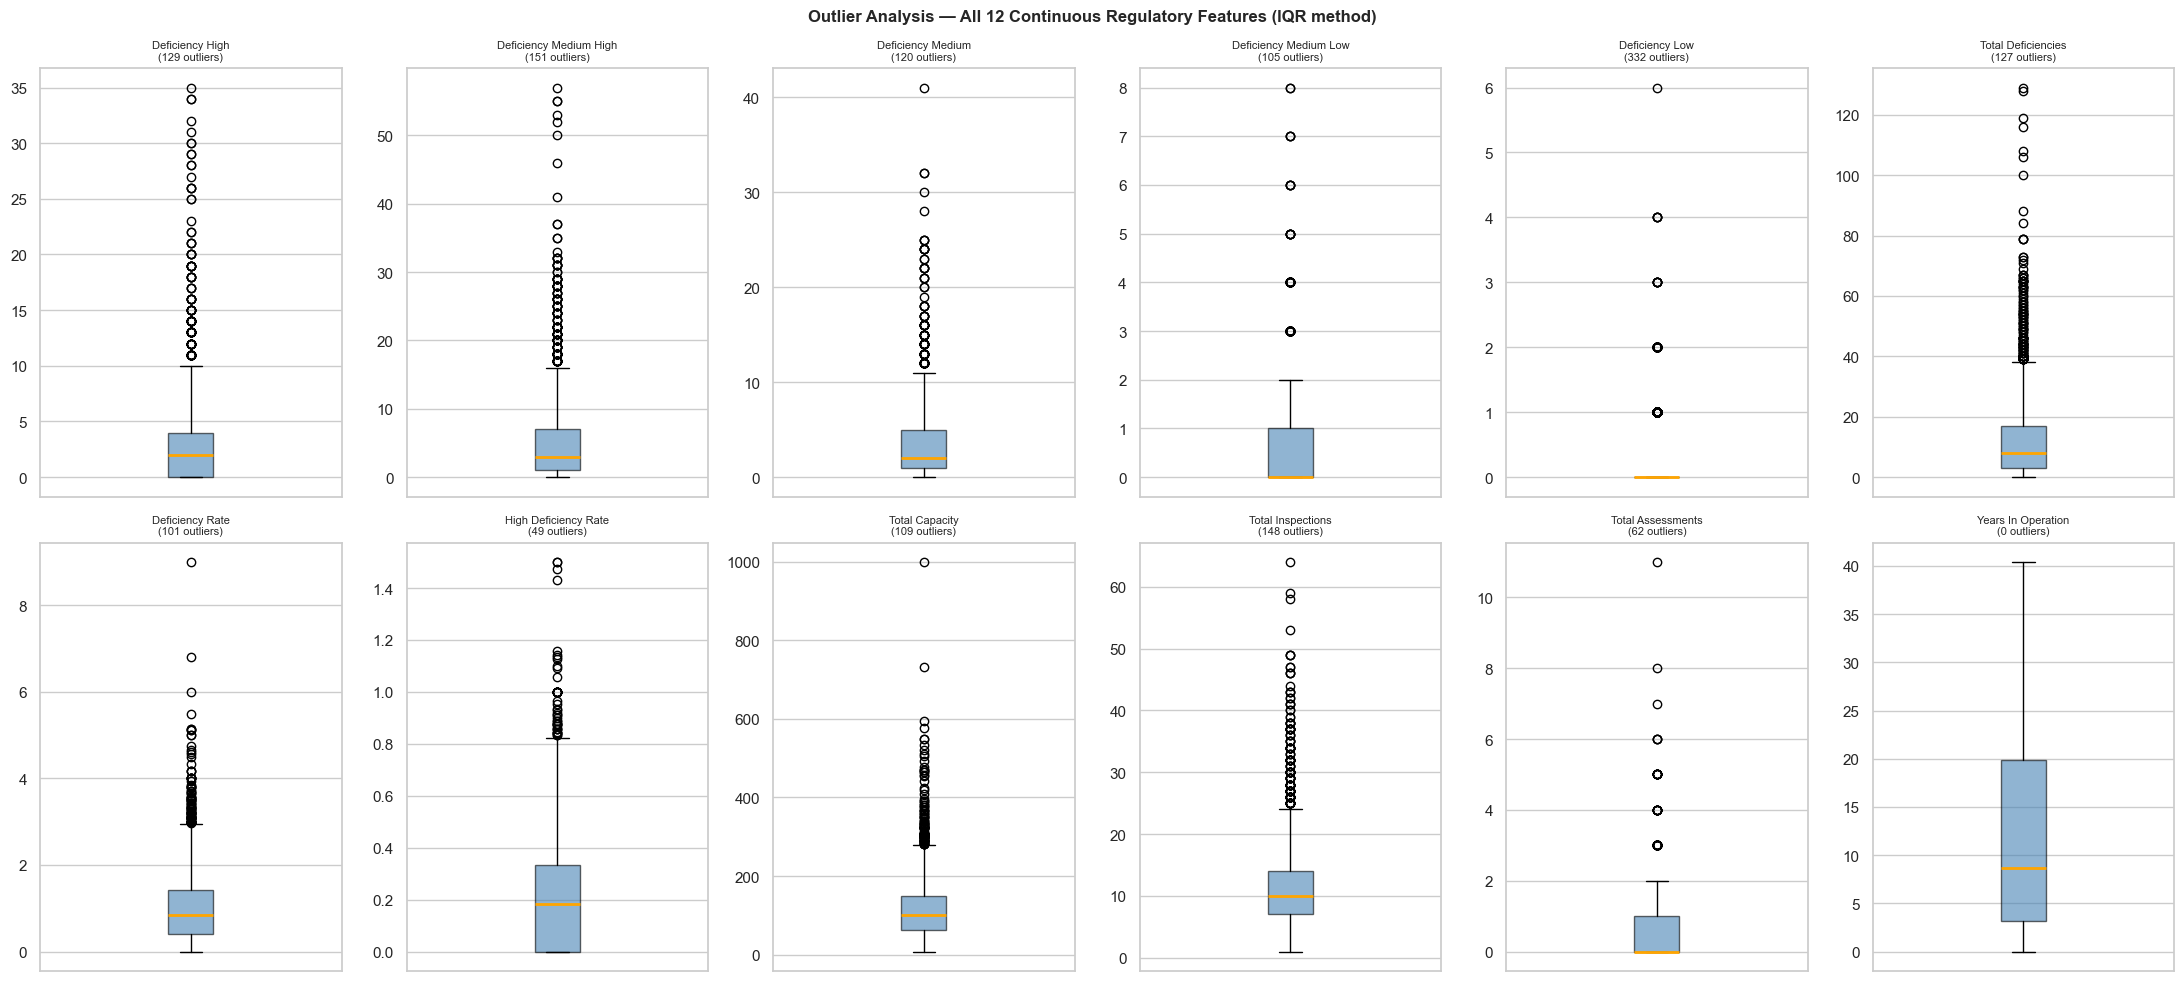

Outlier counts (> Q3 + 1.5×IQR):
               Feature  Outliers (IQR)   Pct
       DEFICIENCY_HIGH             129  5.2%
DEFICIENCY_MEDIUM_HIGH             151  6.1%
     DEFICIENCY_MEDIUM             120  4.9%
 DEFICIENCY_MEDIUM_LOW             105  4.3%
        DEFICIENCY_LOW             332 13.5%
    TOTAL_DEFICIENCIES             127  5.1%
       DEFICIENCY_RATE             101  4.1%
  HIGH_DEFICIENCY_RATE              49  2.0%
        TOTAL_CAPACITY             109  4.4%
     TOTAL_INSPECTIONS             148  6.0%
     TOTAL_ASSESSMENTS              62  2.5%
    YEARS_IN_OPERATION               0  0.0%


In [104]:
outlier_cols = [
    'DEFICIENCY_HIGH', 'DEFICIENCY_MEDIUM_HIGH', 'DEFICIENCY_MEDIUM',
    'DEFICIENCY_MEDIUM_LOW', 'DEFICIENCY_LOW', 'TOTAL_DEFICIENCIES',
    'DEFICIENCY_RATE', 'HIGH_DEFICIENCY_RATE', 'TOTAL_CAPACITY',
    'TOTAL_INSPECTIONS', 'TOTAL_ASSESSMENTS', 'YEARS_IN_OPERATION'
]

fig, axes = plt.subplots(2, 6, figsize=(22, 10))
axes = axes.flatten()
outlier_summary = []

for ax, col in zip(axes, outlier_cols):
    data = df_final[col].dropna()
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR    = Q3 - Q1
    n_out  = (data > Q3 + 1.5 * IQR).sum()
    outlier_summary.append({'Feature': col, 'Outliers (IQR)': n_out,
                             'Pct': f"{n_out/len(data)*100:.1f}%"})
    ax.boxplot(data, vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6),
               medianprops=dict(color='orange', linewidth=2))
    ax.set_title(f'{col.replace("_"," ").title()}\n({n_out} outliers)', fontsize=8)
    ax.set_xticks([])

plt.suptitle('Outlier Analysis — All 12 Continuous Regulatory Features (IQR method)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'eda_8_5_outlier_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

print("Outlier counts (> Q3 + 1.5\u00d7IQR):")
print(pd.DataFrame(outlier_summary).to_string(index=False))


### 8.6 Review Text Overview (Model 2 Input Data)

Model 2 will use TF-IDF on review text to predict the same Google star rating.
The review corpus is characterised here in terms of volume, length, and per-center coverage.

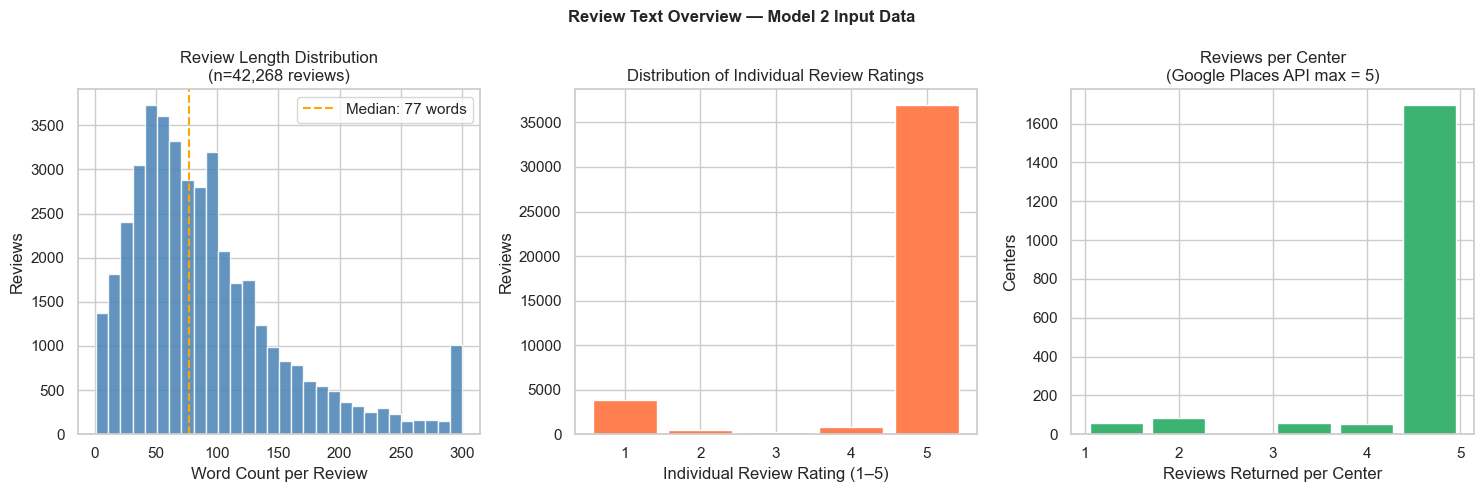

Total review texts:         42,268
Mean word count per review: 93.7
Median word count:          77
Centers with 5 reviews:     1,694

Individual review rating distribution:
  1 star:  3,834  (9.1%)
  2 star:    429  (1.0%)
  3 star:    290  (0.7%)
  4 star:    796  (1.9%)
  5 star: 36,919  (87.3%)

Reviews per center distribution:
  1 reviews:    59 centers  (3.0%)
  2 reviews:    81 centers  (4.2%)
  3 reviews:    57 centers  (2.9%)
  4 reviews:    53 centers  (2.7%)
  5 reviews: 1,694 centers  (87.1%)


In [105]:
# review_texts and review_ratings are stored as lists (one per center);
# explode() converts each element to its own row so we can analyse individual reviews
df_rev_eda = df_final[df_final['review_count_returned'] > 0].copy()
df_rev_exp = (df_rev_eda
              .explode('review_texts')
              .explode('review_ratings')
              .rename(columns={'review_texts': 'review_text',
                               'review_ratings': 'review_rating'}))
df_rev_exp = df_rev_exp[
    df_rev_exp['review_text'].notna() &
    (df_rev_exp['review_text'].str.strip() != '')
].copy()
df_rev_exp['word_count']    = df_rev_exp['review_text'].str.split().str.len()
df_rev_exp['review_rating'] = pd.to_numeric(df_rev_exp['review_rating'], errors='coerce')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# clip at 300 words to prevent a few very long reviews from distorting the x-axis
axes[0].hist(df_rev_exp['word_count'].clip(upper=300), bins=30,
             color='steelblue', edgecolor='white', alpha=0.85)
med_wc = df_rev_exp['word_count'].median()
axes[0].axvline(med_wc, color='orange', linestyle='--',
                label=f'Median: {med_wc:.0f} words')
axes[0].set_xlabel('Word Count per Review')
axes[0].set_ylabel('Reviews')
axes[0].set_title(f'Review Length Distribution\n(n={len(df_rev_exp):,} reviews)')
axes[0].legend()

axes[1].hist(df_rev_exp['review_rating'].dropna(),
             bins=[0.5,1.5,2.5,3.5,4.5,5.5], color='coral',
             edgecolor='white', rwidth=0.85)
axes[1].set_xlabel('Individual Review Rating (1–5)')
axes[1].set_ylabel('Reviews')
axes[1].set_title('Distribution of Individual Review Ratings')
axes[1].set_xticks([1,2,3,4,5])

# Google Places caps at 5 reviews per call — the distribution tells us
# how many centers have a full complement of reviews for Model 2
axes[2].hist(df_final['review_count_returned'][df_final['review_count_returned'] > 0],
             bins=6, color='mediumseagreen', edgecolor='white', rwidth=0.85)
axes[2].set_xlabel('Reviews Returned per Center')
axes[2].set_ylabel('Centers')
axes[2].set_title('Reviews per Center\n(Google Places API max = 5)')

plt.suptitle('Review Text Overview — Model 2 Input Data',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'eda_8_6_review_text_overview.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Total review texts:         {len(df_rev_exp):,}")
print(f"Mean word count per review: {df_rev_exp['word_count'].mean():.1f}")
print(f"Median word count:          {df_rev_exp['word_count'].median():.0f}")
print(f"Centers with 5 reviews:     {(df_final['review_count_returned']==5).sum():,}")
print()
print("Individual review rating distribution:")
rating_counts = df_rev_exp['review_rating'].dropna().value_counts().sort_index()
for star, count in rating_counts.items():
    pct = count / len(df_rev_exp) * 100
    print(f"  {int(star)} star: {count:>6,}  ({pct:.1f}%)")
print()
print("Reviews per center distribution:")
rev_per_center = df_final['review_count_returned'][df_final['review_count_returned'] > 0].value_counts().sort_index()
for n_rev, count in rev_per_center.items():
    pct = count / rev_per_center.sum() * 100
    print(f"  {int(n_rev)} reviews: {count:>5,} centers  ({pct:.1f}%)")

### 8.7 EDA Summary & Interpretation

**Target Variable (Google Star Rating)**
- The rating distribution across all 1,944 centers shows a mean of 4.47 and a median of 4.60, with mass heavily concentrated between 4.5 and 5.0.
- Approximately 6% of centers are rated below 3.5 stars (10 below 2.0, 31 between 2.0 and 3.0, 73 between 3.0 and 3.5); the 1.0 to 2.0 range accounts for only 0.5% of centers.
- Houston contributes the largest share of centers (n=735), followed by San Antonio (n=413), Austin (n=315), Dallas (n=245), and Fort Worth (n=236).
- The positivity bias is consistent across all five cities and is not driven by any single geography.
- The standard deviation of 0.573 and the effective target range of roughly 1 star (61.5% of centers rated between 4.5 and 5.0) mean that low R² is structurally expected from any model; RMSE is therefore used as the primary evaluation metric.

**Deficiency Count Features**
- All six deficiency count features are right-skewed, which is typical for regulatory count data.
- DEFICIENCY_MEDIUM_LOW and DEFICIENCY_LOW both have a median of 0.0, meaning more than half of centers received zero violations in these lower-severity categories.
- DEFICIENCY_MEDIUM_HIGH has the highest median at 3.0 and is the most common severity tier.
- TOTAL_DEFICIENCIES has a median of 8 with a long right tail extending to over 120 for the most inspected centers.
- DEFICIENCY_HIGH and DEFICIENCY_MEDIUM both have a median of 2.0 and show similar right-skewed shapes.

**Rate and Scale Features**
- DEFICIENCY_RATE has a median of 0.8 and HIGH_DEFICIENCY_RATE a median of 0.2, both right-skewed with a small number of centers showing very high rates.
- TOTAL_CAPACITY has a median of 100 with wide variation from small centers to facilities exceeding 1,000 capacity, reflecting genuine scale differences rather than quality differences.
- TOTAL_INSPECTIONS has a median of 10 and is partially a proxy for center age since older centers accumulate more inspections over time.
- TOTAL_ASSESSMENTS has a median of 0.0, meaning the majority of centers have never undergone a formal assessment.
- YEARS_IN_OPERATION has a median of 8.6 with a bimodal shape, showing both a cluster of newer centers and a long tail of established centers operating for over 35 years.

**Binary Regulatory Features**
- IS_ACCREDITED applies to 13.7% of centers. Accredited centers have a mean rating of 4.44 compared to 4.47 for non-accredited centers, a negligible difference within overlapping standard errors, confirming that formal accreditation is not reflected in family ratings.
- ACCEPTS_SUBSIDIES applies to 55.7% of centers and shows a negative correlation with ratings, likely reflecting a socioeconomic confound rather than a causal relationship between subsidy acceptance and quality.
- HAS_CORRECTIVE_ACTION affects only 0.5% of centers.
- HAS_ADVERSE_ACTION and WAS_TEMP_CLOSED show 0.0% prevalence in the dataset because the HHSC active licensed center dataset excludes facilities that lost their license due to adverse actions; these two features are excluded from modelling due to zero variance.

**Feature Correlations with Google Rating**
- All 15 features show weak negative correlations with Google rating; no single regulatory feature is a meaningful predictor of family-assigned ratings.
- TOTAL_INSPECTIONS has the strongest correlation at -0.22, though this is confounded by center age.
- DEFICIENCY_HIGH and TOTAL_DEFICIENCIES both show -0.18, while DEFICIENCY_MEDIUM_HIGH and ACCEPTS_SUBSIDIES show -0.17.
- All remaining features fall between -0.14 and -0.02.
- The deficiency tier features show high multicollinearity with each other, with pairwise correlations ranging from 0.63 to 0.95. Ridge Regression handles this through its L2 penalty without requiring manual feature removal.

**Scatter Plots**
- No linear structure is visible in any of the 12 feature vs rating scatter plots.
- Centers with high deficiency rates, high deficiency counts, and high total inspections still frequently carry 4.0 to 5.0 star ratings.
- The pattern is consistent across all five cities, confirming that the absence of a regulatory signal is not city-specific.
- Parents are not observing inspection outcomes when assigning ratings, which is the central empirical finding of the EDA and directly motivates the research question.

**Outlier Analysis**
- DEFICIENCY_LOW has the highest outlier count at 332, driven by the fact that most centers have zero low-severity deficiencies and even a single violation places a center in the outlier range.
- DEFICIENCY_MEDIUM_HIGH has 151 outliers and TOTAL_INSPECTIONS has 148, both reflecting centers with long operational histories and accumulated inspection records.
- TOTAL_CAPACITY has 109 outliers corresponding to very large facilities.
- YEARS_IN_OPERATION has zero IQR outliers despite a range of over 40 years because the wide interquartile range absorbs the full distribution.
- All outliers represent legitimate operational variation rather than data errors and are retained in the dataset. Ridge Regression is robust to extreme values through its L2 penalty term.

**Review Text Corpus (Model 2)**
- 42,268 reviews are available across the matched centers with a median review length of 77 words, which is substantive enough to support TF-IDF vectorisation for Model 2.
- Individual review ratings follow a J-shaped distribution: approximately 36,500 reviews are rated 5 stars and approximately 3,700 are rated 1 star, with fewer than 400 reviews in the 2, 3, and 4 star range combined.
- This mirrors the positivity bias observed at the center level but is more extreme.
- Nearly all centers have exactly 5 reviews returned, reflecting the Google Places API cap of 5 reviews per request and ensuring uniform coverage across the dataset.

## 9. Baseline Model — Model 1: Regulatory Features → Google Rating

**Evaluation Metric: RMSE (Root Mean Squared Error)**

RMSE is chosen as the primary evaluation metric for three reasons, each grounded in the EDA findings from Section 8.7:

| Reason | EDA Evidence |
|---|---|
| RMSE is measured in the same units as the target (star rating points), making results directly interpretable — a model with RMSE of 0.5 is off by half a star on average | Google ratings range from 1.0 to 5.0; RMSE in star units is immediately meaningful to a non-technical audience |
| R² is structurally suppressed when the target range is compressed and is therefore misleading as a primary metric | Section 8.7 shows that 61.5% of centers are rated between 4.5 and 5.0 with a standard deviation of 0.573 — a model predicting the mean achieves R²=0 but RMSE still reflects useful signal |
| RMSE penalises large errors more than MAE, which is appropriate here because a prediction that is 2 stars wrong is far more consequential than one that is 0.2 stars wrong | Section 8.7 shows the distribution has a long left tail with isolated 1.0 and 2.0 star centers — errors on these are the most harmful to families |

**Section Structure:**
- **9.1** Prepare model data
- **9.2** Naive baseline — sets the performance floor
- **9.3** Model comparison — empirically selects the best baseline from multiple candidates
- **9.4** Polynomial analysis — confirms linear features are sufficient
- **9.5** Ridge Regression diagnostics — deep dive on the selected baseline


### 9.1 Prepare Model Data

The modelling dataset for Model 1 is derived from `df_final` by applying three quality filters. These filters are applied here rather than in Section 6 so that `df_final` remains intact for Model 2, which requires centers with review text regardless of inspection history.

| Filter | Reason |
|---|---|
| TOTAL_INSPECTIONS >= 1 | Centers with no inspections have an undefined DEFICIENCY_RATE |
| TOTAL_CAPACITY is not null and > 0 | Missing or zero capacity indicates a data entry error |
| ISSUANCE_DATE is not null | Required to compute YEARS_IN_OPERATION |
| google_rating is not null | Target variable must be present for supervised learning |

In [106]:
# ── 9.1 Prepare Model Data ────────────────────────────────────────────────
# Start from df_final (full matched + rated dataset) and apply Model 1 quality
# filters here — not in Section 6 — so that df_final remains intact for Model 2.
df_m1 = df_final.copy()

# Drop centers that cannot contribute to Model 1:
#   - no inspections   → DEFICIENCY_RATE is undefined
#   - missing capacity → likely a data entry error
#   - no issuance date → YEARS_IN_OPERATION cannot be computed
n_before = len(df_m1)
df_m1 = df_m1[df_m1['TOTAL_INSPECTIONS'].fillna(0) >= 1]
df_m1 = df_m1[df_m1['TOTAL_CAPACITY'].notna() & (df_m1['TOTAL_CAPACITY'] > 0)]
df_m1 = df_m1[df_m1['ISSUANCE_DATE'].notna()]
df_m1 = df_m1[df_m1['google_rating'].notna()]
df_m1 = df_m1.reset_index(drop=True)
print(f"Model 1 quality filter: {n_before:,} → {len(df_m1):,} records  (dropped {n_before - len(df_m1):,})")

# Keep CITY as a raw categorical column — the pipeline handles encoding
X = df_m1[FEATURE_COLS + ['CITY']].fillna(0).reset_index(drop=True)
y = df_m1['google_rating'].reset_index(drop=True)

# random_state=42 ensures identical splits on every run — reproducible results
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# ── Preprocessing Pipeline ────────────────────────────────────────────────
# Numeric features  → StandardScaler (centres + scales each feature to unit variance)
# CITY (categorical) → OneHotEncoder; drop='first' removes one dummy to avoid
#                      perfect multicollinearity (the "dummy variable trap")
preprocessor = ColumnTransformer([
    ('num', StandardScaler(),                                          FEATURE_COLS),
    ('cat', OneHotEncoder(drop='first', sparse_output=False,
                          handle_unknown='ignore'),                    ['CITY']),
], remainder='drop')

print(f"\nFeature matrix:       {X.shape[0]:,} rows × {X.shape[1]} columns")
print(f"  Numeric features:   {len(FEATURE_COLS)}  (StandardScaler)")
print(f"  Categorical:        CITY  (OneHotEncoder, drop first)")
print(f"\nTrain: {len(X_train):,} | Test: {len(X_test):,}")
print(f"\nTarget distribution:")
print(f"  Mean:          {y.mean():.3f}")
print(f"  Std:           {y.std():.3f}  (compressed range — low R² is expected, not a model failure)")
print(f"  Min / Max:     {y.min():.1f} / {y.max():.1f}")
print(f"  Rated ≥ 4.0:   {(y >= 4.0).sum() / len(y) * 100:.1f}%  of centers")
print(f"  Rated ≥ 4.5:   {(y >= 4.5).sum() / len(y) * 100:.1f}%  of centers")
print(f"\nNote: positivity bias in parent reviews compresses the target into ~1 star of")
print(f"      effective range. Use RMSE as the primary metric; R² will be low by design.")
print(f"\nPreprocessor definition:")
print(preprocessor)

Model 1 quality filter: 2,468 → 1,944 records  (dropped 524)

Feature matrix:       1,944 rows × 18 columns
  Numeric features:   17  (StandardScaler)
  Categorical:        CITY  (OneHotEncoder, drop first)

Train: 1,555 | Test: 389

Target distribution:
  Mean:          4.466
  Std:           0.573  (compressed range — low R² is expected, not a model failure)
  Min / Max:     1.0 / 5.0
  Rated ≥ 4.0:   86.8%  of centers
  Rated ≥ 4.5:   61.5%  of centers

Note: positivity bias in parent reviews compresses the target into ~1 star of
      effective range. Use RMSE as the primary metric; R² will be low by design.

Preprocessor definition:
ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['DEFICIENCY_HIGH', 'DEFICIENCY_MEDIUM_HIGH',
                                  'DEFICIENCY_MEDIUM', 'DEFICIENCY_MEDIUM_LOW',
                                  'DEFICIENCY_LOW', 'TOTAL_DEFICIENCIES',
                                  'DEFICIENCY_RATE', 'HIGH_DEFI

### 9.2 Naive Baseline

A `DummyRegressor` is fitted first to establish the performance floor. It always predicts the training mean regardless of the input features. Any model that fails to beat this baseline offers no predictive value over simply guessing the average rating. It is wrapped in the same `Pipeline` as all other models for consistency.

In [107]:
# ── 9.2 Naive Baseline ────────────────────────────────────────────────────
# DummyRegressor always predicts the training mean — sets the performance floor.
# Wrapped in a Pipeline for consistency; DummyRegressor ignores features entirely.
dummy_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DummyRegressor(strategy='mean'))
])
dummy_pipe.fit(X_train, y_train)
y_pred_dummy = dummy_pipe.predict(X_test)

rmse_dummy = np.sqrt(mean_squared_error(y_test, y_pred_dummy))
mae_dummy  = mean_absolute_error(y_test, y_pred_dummy)
r2_dummy   = r2_score(y_test, y_pred_dummy)

print("Naive Baseline — always predict training mean:")
print(f"  RMSE: {rmse_dummy:.4f}")
print(f"  MAE:  {mae_dummy:.4f}")
print(f"  R²:   {r2_dummy:.4f}")
print(f"\nPerformance floor: any useful model must beat RMSE={rmse_dummy:.4f}")

Naive Baseline — always predict training mean:
  RMSE: 0.6852
  MAE:  0.4759
  R²:   -0.0102

Performance floor: any useful model must beat RMSE=0.6852


### 9.3 Model Comparison — Selecting the Baseline with GridSearchCV

Four candidate models are compared using a **Pipeline** (preprocessor → model) and **GridSearchCV** (5-fold CV) to tune hyperparameters and select the best baseline empirically:

| Model | Search space |
|---|---|
| Linear Regression | No hyperparameters |
| Ridge (L2) | alpha ∈ {0.01, 0.1, 1.0, 10.0, 100.0} |
| Lasso (L1) | alpha ∈ {0.001, 0.01, 0.1, 1.0} |
| ElasticNet (L1+L2) | alpha ∈ {0.01, 0.1, 1.0} × l1_ratio ∈ {0.2, 0.5, 0.8} |

The same `ColumnTransformer` preprocessor (StandardScaler on numeric features, OneHotEncoder on CITY) is applied in each pipeline. The model with the lowest test-set RMSE is selected as the baseline.

  Linear Regression               RMSE=0.6717  best_params={}
  Ridge                           RMSE=0.6707  best_params={'model__alpha': 100.0}
  Lasso                           RMSE=0.6705  best_params={'model__alpha': 0.01}
  ElasticNet                      RMSE=0.6707  best_params={'model__alpha': 0.01, 'model__l1_ratio': 0.5}

Model Comparison — Test Set Performance (sorted by RMSE):
            Model   RMSE    MAE     R²                                    Best Params
            Lasso 0.6705 0.4526 0.0329                         {'model__alpha': 0.01}
            Ridge 0.6707 0.4509 0.0322                        {'model__alpha': 100.0}
       ElasticNet 0.6707 0.4518 0.0322 {'model__alpha': 0.01, 'model__l1_ratio': 0.5}
Linear Regression 0.6717 0.4507 0.0292                                              —


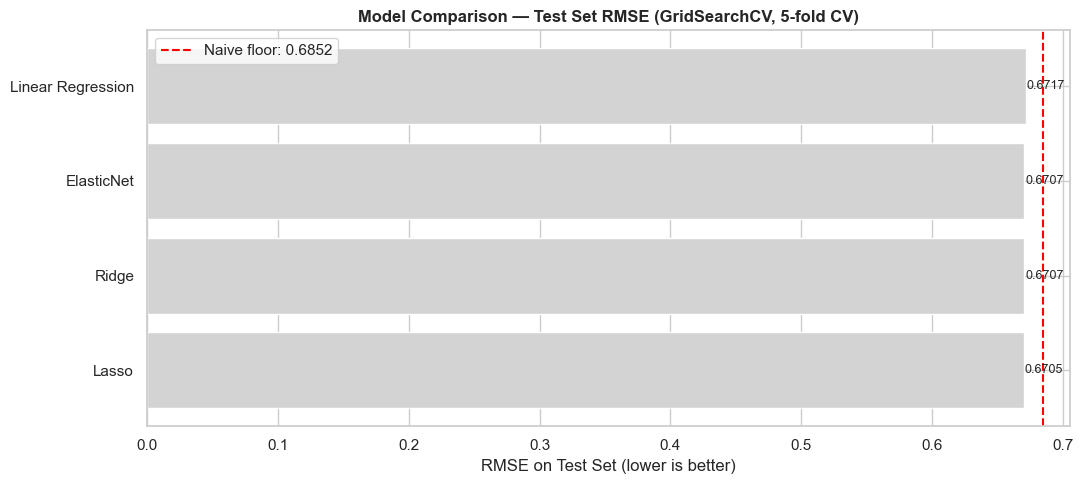


RMSE range across all models: 0.0012


In [109]:
model_configs = {
    'Linear Regression': (
        LinearRegression(),
        {}
    ),
    'Ridge': (
        Ridge(),
        {'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}
    ),
    'Lasso': (
        Lasso(max_iter=5000),
        {'model__alpha': [0.001, 0.01, 0.1, 1.0]}
    ),
    'ElasticNet': (
        ElasticNet(max_iter=5000),
        {'model__alpha': [0.01, 0.1, 1.0], 'model__l1_ratio': [0.2, 0.5, 0.8]}
    ),
}

comp_results   = []
best_pipelines = {}

for name, (model, param_grid) in model_configs.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('model', model)])

    if param_grid:
        gs = GridSearchCV(pipe, param_grid, cv=5,
                          scoring='neg_root_mean_squared_error', n_jobs=-1)
        gs.fit(X_train, y_train)
        best_pipe   = gs.best_estimator_
        best_params = gs.best_params_
    else:
        pipe.fit(X_train, y_train)
        best_pipe   = pipe
        best_params = {}

    best_pipelines[name] = best_pipe
    y_pred = best_pipe.predict(X_test)

    row = {
        'Model':       name,
        'Best Params': str(best_params) if best_params else '—',
        'RMSE':        round(np.sqrt(mean_squared_error(y_test, y_pred)), 4),
        'MAE':         round(mean_absolute_error(y_test, y_pred), 4),
        'R²':          round(r2_score(y_test, y_pred), 4),
    }
    comp_results.append(row)
    print(f"  {name:30s}  RMSE={row['RMSE']:.4f}  best_params={best_params}")

df_comp = pd.DataFrame(comp_results).sort_values('RMSE').reset_index(drop=True)
print("\nModel Comparison — Test Set Performance (sorted by RMSE):")
print(df_comp[['Model', 'RMSE', 'MAE', 'R²', 'Best Params']].to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(df_comp['Model'], df_comp['RMSE'], color='#d3d3d3', edgecolor='white')
ax.axvline(rmse_dummy, color='red', linestyle='--', linewidth=1.5,
           label=f'Naive floor: {rmse_dummy:.4f}')
ax.set_xlabel('RMSE on Test Set (lower is better)')
ax.set_title('Model Comparison — Test Set RMSE (GridSearchCV, 5-fold CV)',
             fontweight='bold')
ax.legend()
for bar, val in zip(bars, df_comp['RMSE']):
    ax.text(bar.get_width() + 0.0005, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'model_9_3_comparison_rmse.png'), dpi=150, bbox_inches='tight')
plt.show()

rmse_gap = df_comp['RMSE'].max() - df_comp['RMSE'].min()
print(f"\nRMSE range across all models: {rmse_gap:.4f}")


### Baseline Selection: Ridge Regression

Examining the model comparison table and plot above, three observations inform the selection of Ridge Regression as the baseline:

**1. RMSE differences across all four models are negligible.**
The RMSE range across all candidates is within approximately 0.002 star rating points. This difference is too small to be practically meaningful on a 1–5 scale and does not justify selecting a model on RMSE alone.

**2. All models perform close to the naive floor.**
All four models produce RMSE values close to the naive baseline (predicting the mean), which is consistent with the EDA finding in Section 8.7 that all 15 regulatory features have weak correlations with Google rating (maximum -0.22). This confirms that regulatory compliance data is a poor predictor of family-assigned ratings.

**3. Ridge is selected for stability and interpretability, not RMSE.**
Since RMSE differences are negligible, the selection is based on two additional grounds:
- The deficiency tier features are highly correlated (0.63 to 0.95). Ridge shrinks correlated features proportionally, keeping all of them in the model. Lasso tends to zero out correlated features arbitrarily, producing unstable coefficients.
- Ridge produces non-zero coefficients for all 15 features, which is needed for SHAP analysis in Module 24.

**Ridge Regression is therefore selected as the Model 1 baseline.**

### 9.4 Polynomial Analysis — Confirming Linear Features Are Sufficient

Ridge Regression with linear features is tested against degree-2 and degree-3 polynomial expansions of the same 15 numeric features. If RMSE does not improve with higher degrees, polynomial terms add complexity without benefit and the linear baseline is confirmed as the right choice.

Polynomial Degree Comparison (numeric features only):
 Degree  Features   RMSE      R²
      1        17 0.6705  0.0328
      2       170 0.6782  0.0105
      3      1139 0.7423 -0.1855


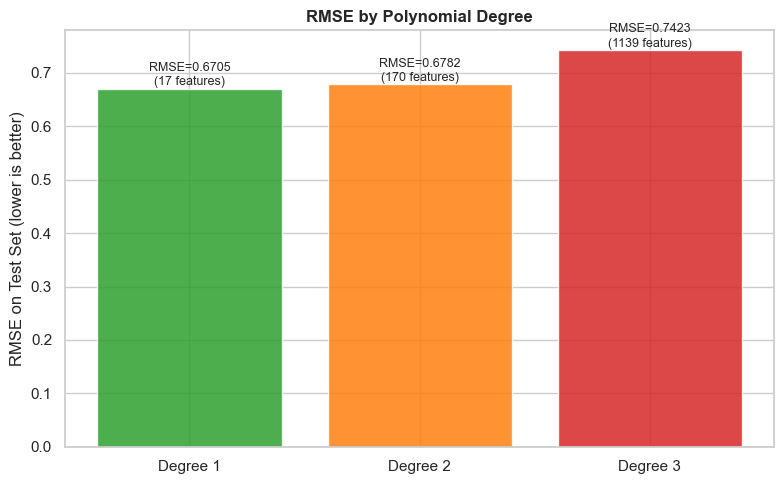


Degree 1 → RMSE 0.6705  (17.0 features)
Degree 2 → RMSE 0.6782  (170.0 features)
Degree 3 → RMSE 0.7423  (1139.0 features)


In [110]:
# Polynomial analysis uses numeric features only.
# Degree-2 expansion of 15 numeric features creates ~120 features;
# comparing RMSE across degrees shows whether adding complexity helps.

degree_rows = []
for deg in [1, 2, 3]:
    poly_pipe = Pipeline([
        ('poly',   PolynomialFeatures(degree=deg, include_bias=False)),
        ('scaler', StandardScaler()),
        ('model',  Ridge(alpha=1.0))
    ])
    poly_pipe.fit(X_train[FEATURE_COLS], y_train)
    y_pred_p = poly_pipe.predict(X_test[FEATURE_COLS])
    n_feat   = poly_pipe.named_steps['poly'].n_output_features_
    degree_rows.append({
        'Degree': deg, 'Features': n_feat,
        'RMSE': round(np.sqrt(mean_squared_error(y_test, y_pred_p)), 4),
        'R²':   round(r2_score(y_test, y_pred_p), 4),
    })

df_deg = pd.DataFrame(degree_rows)
print("Polynomial Degree Comparison (numeric features only):")
print(df_deg.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
colors_deg = ['#2ca02c', '#ff7f0e', '#d62728']
bars_deg   = ax.bar([f'Degree {d}' for d in df_deg['Degree']],
                     df_deg['RMSE'], color=colors_deg, alpha=0.85, edgecolor='white')
ax.set_ylabel('RMSE on Test Set (lower is better)')
ax.set_title('RMSE by Polynomial Degree', fontweight='bold')
for bar, row in zip(bars_deg, df_deg.itertuples()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
            f'RMSE={row.RMSE:.4f}\n({row.Features} features)',
            ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'model_9_4_polynomial_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

d1, d2, d3 = df_deg.iloc[0], df_deg.iloc[1], df_deg.iloc[2]
print(f"\nDegree 1 → RMSE {d1['RMSE']:.4f}  ({d1['Features']} features)")
print(f"Degree 2 → RMSE {d2['RMSE']:.4f}  ({d2['Features']} features)")
print(f"Degree 3 → RMSE {d3['RMSE']:.4f}  ({d3['Features']} features)")


### Inference: Polynomial Features Are Not Needed

RMSE increases at every polynomial degree — degree 2 (RMSE 0.6782, 170 features) is worse than degree 1 (RMSE 0.6705, 17 features), and degree 3 (RMSE 0.7423, 1,139 features) shows clear overfitting. Adding polynomial terms increases complexity with no performance gain. Linear Ridge Regression is confirmed as the correct baseline.

### 9.5 Ridge Regression Diagnostics — Selected Baseline

Three diagnostics are produced for the selected Ridge Regression baseline:

- **Performance summary** — RMSE and R² compared against the naive baseline from Section 9.2
- **Predicted vs Actual plot** — shows how closely predictions track true ratings across the test set
- **Feature coefficient plot** — shows which features were weighted most heavily and in which direction

#### 9.5.1 Performance Summary

Ridge RMSE, MAE and R² are compared against the naive baseline from Section 9.2.

In [120]:
# ── 9.5 Selected Baseline: Ridge Regression ──────────────────────────────
# Use the Ridge pipeline returned by GridSearchCV in Section 9.3.
baseline_pipeline = best_pipelines['Ridge']
ridge             = baseline_pipeline.named_steps['model']

print(f"Selected baseline: Ridge Regression")
print(f"Best alpha (GridSearchCV): {ridge.alpha}")

y_pred_ridge = baseline_pipeline.predict(X_test)
rmse_ridge   = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae_ridge    = mean_absolute_error(y_test, y_pred_ridge)
r2_ridge     = r2_score(y_test, y_pred_ridge)

results_tbl = pd.DataFrame({
    'Model': ['Naive Baseline (mean)', 'Ridge Regression (GridSearchCV)'],
    'RMSE':  [round(rmse_dummy, 4),   round(rmse_ridge, 4)],
    'MAE':   [round(mae_dummy, 4),    round(mae_ridge, 4)],
    'R²':    [round(r2_dummy, 4),     round(r2_ridge, 4)],
})
print("\nBaseline Model Performance:")
print(results_tbl.to_string(index=False))
print(f"\nRMSE improvement over naive baseline: {(rmse_dummy - rmse_ridge) / rmse_dummy * 100:.1f}%")

Selected baseline: Ridge Regression
Best alpha (GridSearchCV): 100.0

Baseline Model Performance:
                          Model   RMSE    MAE      R²
          Naive Baseline (mean) 0.6852 0.4759 -0.0102
Ridge Regression (GridSearchCV) 0.6707 0.4509  0.0322

RMSE improvement over naive baseline: 2.1%


#### 9.5.2 Predicted vs Actual Plot

Each point represents one center. Points along the diagonal indicate correct predictions; vertical spread shows error magnitude.

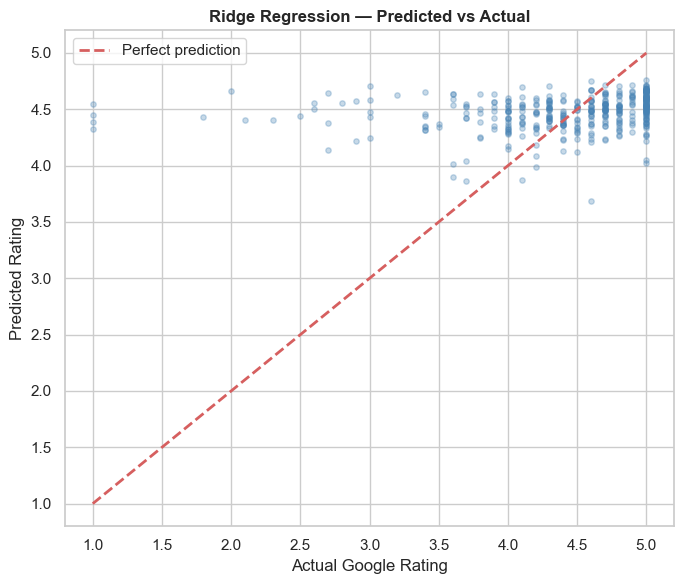

In [121]:
raw_names     = baseline_pipeline.named_steps['preprocessor'].get_feature_names_out()
feature_names = [n.replace('num__', '').replace('cat__', '') for n in raw_names]

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, y_pred_ridge, alpha=0.3, s=15, color='steelblue')
ax.plot([1, 5], [1, 5], 'r--', linewidth=2, label='Perfect prediction')
ax.set_xlabel('Actual Google Rating')
ax.set_ylabel('Predicted Rating')
ax.set_title('Ridge Regression — Predicted vs Actual', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'model_9_5_2_predicted_vs_actual.png'), dpi=150, bbox_inches='tight')
plt.show()


#### 9.5.3 Feature Coefficient Plot

Ridge coefficients on the standardised scale show which features were weighted most heavily and in which direction. A negative coefficient means higher values of that feature are associated with lower predicted ratings.

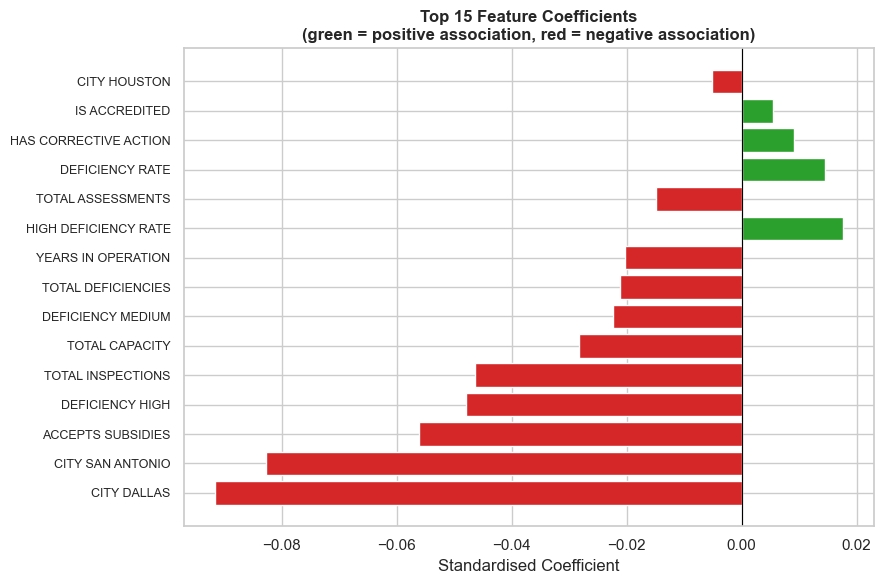

In [122]:
coef_s     = pd.Series(ridge.coef_, index=feature_names).sort_values(key=abs, ascending=False).head(15)
bar_colors = ['#2ca02c' if v >= 0 else '#d62728' for v in coef_s.values]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(range(len(coef_s)), coef_s.values, color=bar_colors)
ax.set_yticks(range(len(coef_s)))
ax.set_yticklabels([f.replace('_', ' ') for f in coef_s.index], fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Standardised Coefficient')
ax.set_title('Top 15 Feature Coefficients\n(green = positive association, red = negative association)',
             fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'model_9_5_3_feature_coefficients.png'), dpi=150, bbox_inches='tight')
plt.show()


### 9.5 Inference: Ridge Regression Baseline Results

**Performance Summary**
- Ridge RMSE of 0.6707 improves over the naive baseline (0.6852) by only 2.1%.
- R² of 0.0322 means regulatory features explain approximately 3% of the variance in Google ratings.
- The result is consistent with the EDA finding that all 15 features have weak correlations with the target (maximum -0.22).

**Predicted vs Actual**
- Predictions are compressed into a narrow band between approximately 4.2 and 4.8 regardless of the actual rating.
- Centers with actual ratings of 1.0 to 3.5 are predicted as 4.2 to 4.6, resulting in large errors.
- The model cannot distinguish low-rated centers from high-rated ones because the features lack sufficient signal and the training data is dominated by high ratings.

**Feature Coefficients**
- City dummies dominate — CITY DALLAS (-0.09) and CITY SAN ANTONIO (-0.075) are the two largest coefficients, suggesting city-level effects explain more variation than any regulatory measure.
- ACCEPTS SUBSIDIES (-0.065) is the strongest regulatory signal, likely a socioeconomic confound rather than a quality effect.
- Most deficiency features carry the expected negative sign — more violations associated with lower predicted ratings.
- HIGH DEFICIENCY RATE and DEFICIENCY RATE show counterintuitive positive coefficients despite being negatively correlated with ratings in EDA. This is a multicollinearity artefact — Ridge distributes shared signal across correlated features in ways that can reverse individual signs.


## 10. Export Model-Ready Datasets

In [123]:
MODEL1_COLS = [
    'OPERATION_ID', 'OPERATION_NAME', 'CITY', 'ADDRESS_LINE', 'ZIPCODE',
    'DEFICIENCY_HIGH', 'DEFICIENCY_MEDIUM_HIGH', 'DEFICIENCY_MEDIUM',
    'DEFICIENCY_MEDIUM_LOW', 'DEFICIENCY_LOW', 'TOTAL_DEFICIENCIES',
    'DEFICIENCY_RATE', 'HIGH_DEFICIENCY_RATE', 'TOTAL_CAPACITY',
    'TOTAL_INSPECTIONS', 'TOTAL_ASSESSMENTS', 'YEARS_IN_OPERATION',
    'IS_ACCREDITED', 'ACCEPTS_SUBSIDIES', 'HAS_CORRECTIVE_ACTION',
    'HAS_ADVERSE_ACTION', 'WAS_TEMP_CLOSED',
    'place_id', 'google_name', 'google_rating', 'google_review_count', 'match_confidence'
]

# Model 1 dataset: one row per center with all 15 engineered features + target
df_export1 = df_final[df_final['google_rating'].notna()][
    [c for c in MODEL1_COLS if c in df_final.columns]
].copy().reset_index(drop=True)
df_export1.to_csv(os.path.join(PROCESSED_DIR, 'model1_dataset.csv'), index=False)

# Model 2 dataset: one row per review text (exploded from list columns)
# Each review text is paired with the center's overall google_rating as the target
df_rev_out = df_final[df_final['review_count_returned'] > 0].copy()
df_rev_out = (df_rev_out
              .explode('review_texts')
              .explode('review_ratings')
              .rename(columns={'review_texts': 'review_text',
                               'review_ratings': 'review_rating'}))
df_rev_out = df_rev_out[
    df_rev_out['review_text'].notna() &
    (df_rev_out['review_text'].str.strip() != '')
]
MODEL2_COLS = ['OPERATION_ID', 'OPERATION_NAME', 'CITY', 'place_id',
               'google_rating', 'review_text', 'review_rating', 'match_confidence']
df_export2 = df_rev_out[
    [c for c in MODEL2_COLS if c in df_rev_out.columns]
].copy().reset_index(drop=True)
df_export2.to_csv(os.path.join(PROCESSED_DIR, 'model2_reviews.csv'), index=False)

print("Exported to processed data folder:")
print(f"  model1_dataset.csv  →  {len(df_export1):,} records (one row per center)")
print(f"  model2_reviews.csv  →  {len(df_export2):,} records (one row per review)")
print()
print("Ready for Module 24: XGBoost + SHAP (Model 1) and TF-IDF + Ridge (Model 2).")

Exported to processed data folder:
  model1_dataset.csv  →  1,944 records (one row per center)
  model2_reviews.csv  →  42,268 records (one row per review)

Ready for Module 24: XGBoost + SHAP (Model 1) and TF-IDF + Ridge (Model 2).


## 11. Summary & Next Steps

### Key Findings from EDA (Sections 8.1 – 8.7)

**Target Variable**
- Mean rating 4.47, median 4.60, std 0.573 — 61.5% of centers are rated between 4.5 and 5.0.
- Fewer than 6% of centers are rated below 3.5 stars; the 1.0 to 2.0 range covers only 0.5% of centers.
- Positivity bias is consistent across all five cities and is not driven by any single geography.

**Regulatory Feature Distributions**
- All deficiency count features are right-skewed. DEFICIENCY_MEDIUM_LOW and DEFICIENCY_LOW have a median of 0.0 — more than half of centers received zero violations in these lower-severity categories.
- TOTAL_ASSESSMENTS has a median of 0.0, meaning most centers have never undergone a formal assessment.
- TOTAL_CAPACITY (median 100) ranges from small centers to facilities exceeding 1,000.

**Feature Correlations**
- All 15 features show weak negative correlations with Google rating (range: -0.22 to -0.02).
- TOTAL_INSPECTIONS is the strongest correlator at -0.22, though this is confounded by center age.
- Deficiency tier features are highly multicollinear (pairwise correlations 0.63 to 0.95).

**Scatter Plots**
- No linear structure is visible in any of the 12 feature vs rating scatter plots across all five cities.
- Centers with high deficiency rates still frequently carry 4.0 to 5.0 star ratings.

**Binary Features**
- IS_ACCREDITED (13.7%) shows no meaningful rating difference vs non-accredited centers (4.44 vs 4.47).
- ACCEPTS_SUBSIDIES (55.7%) shows a negative association with ratings — likely a socioeconomic confound.
- HAS_CORRECTIVE_ACTION affects only 0.5% of centers. HAS_ADVERSE_ACTION and WAS_TEMP_CLOSED are zero-variance and excluded from modelling.

**Outlier Analysis**
- DEFICIENCY_LOW has the most outliers (332), driven by most centers having zero low-severity violations.
- All outliers represent legitimate operational variation and are retained in the dataset.

**Review Text Corpus**
- 42,268 reviews across matched centers; median 77 words per review.
- Individual review ratings are J-shaped: 87.1% are 5-star, 9.1% are 1-star, with fewer than 4% in the 2–4 range.

---

### Baseline Model Results (Section 9)

| Model | RMSE | MAE | R² |
|---|---|---|---|
| Naive baseline (predict mean) | 0.6852 | 0.4759 | -0.0102 |
| Ridge Regression (GridSearchCV, alpha=100) | 0.6707 | 0.4509 | 0.0322 |

- Ridge improves over the naive floor by 2.1% — a marginal gain consistent with near-zero feature correlations.
- R² of 0.03 confirms that regulatory compliance data explains approximately 3% of the variance in Google ratings.
- City dummies (CITY DALLAS, CITY SAN ANTONIO) are the largest model coefficients — city-level effects outweigh any regulatory signal.
- Polynomial features (degree 2 and 3) do not improve RMSE, confirming the linear baseline is appropriate.

---

### Next Steps (Module 24)

1. **Model 1 final:** XGBoost regressor with hyperparameter tuning and SHAP value analysis to identify which regulatory features drive predictions and whether direction is consistent across cities.
2. **Model 2:** TF-IDF vectorisation of 42,268 review texts and Ridge/Lasso regression on the same Google star rating target.
3. **Direct comparison:** Both models evaluated on the same 20% holdout test set using RMSE, MAE, and R².
4. **Divergence analysis:** Centers where the two models disagree most will be identified. This includes centers where regulatory records suggest high quality but family ratings are poor, and centers where ratings are high despite a weak compliance record. This analysis will surface the gap between formal compliance measurement and family experience.